# Firn / Ice Temperature Analysis — Advection vs No-Advection

Compares two GloGEM runs for the Aletsch–Morteratsch catchment:

| Run | Folder | Settings |
|-----|--------|----------|
| **ADV** | `adv/` | `enable_advection='y'`, `use_flow_model='y'` |
| **NO_ADV** | `no_adv/` | `enable_advection='n'`, `use_flow_model='y'` |

| Section | What it shows |
|---------|---------------|
| 1 | 2D temperature maps: elevation × time, both runs side-by-side |
| 2 | **Advection effect** ΔT = ADV − NO_ADV: elevation × time maps + elevation profile |
| 3 | Ice-temperature cross-section: elevation × depth (both runs + difference) |
| 3b | Real glacier cross-section (x = distance, y = elevation) colored by ice temperature, for several years (needs `write_geometry_output='y'`) |
| 4 | Temperature evolution at key elevations (both runs overlaid) |
| 5 | Full depth profiles from point-profile output |
| 6 | Realism assessment: lapse rates, histograms, advection-file plots, statistics table |

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from cmcrameri import cm as cmc

from icetemp.plots import CMAP_TEMP, CMAP_DIFF, NODATA_THRESH, apply_style

apply_style()

# Run identifiers and display properties
RUNS       = ('adv', 'no_adv')
RUN_LABELS = {'adv': 'Advection ON',  'no_adv': 'Advection OFF'}
RUN_COLORS = {'adv': cmc.lapaz(0.25), 'no_adv': cmc.lapaz(0.72)}
RUN_LS     = {'adv': '-',             'no_adv': '--'}

print('Imports OK')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  ← set BASE_DIR and FIRNICE_SUBPATH before running
# ─────────────────────────────────────────────────────────────────────────────

# Root folder containing the two run directories (adv/ and no_adv/)
BASE_DIR = '/scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development/icetemp_test_aletsch_morteratsch'

# Sub-path from the run folder to the firnice_temperature/ directory.
# This run used a GCM/projection config (not a hindcast), so output lives under
# the GCM/scenario path:
FIRNICE_SUBPATH = 'monthly/CentralEurope/files/BCC-CSM2-MR/ssp126/firnice_temperature'
# For a hindcast run (reanalysis_direct='y' in config.pro), it would instead be:
# FIRNICE_SUBPATH = 'monthly/CentralEurope/PAST/firnice_temperature'

# Sub-path to the flowline geometry history (.sav files), written by
# save_geometry_output.pro when write_geometry_output='y'. Sibling directory
# to firnice_temperature under the same scenario path, so derived automatically.
GEOMETRY_SUBPATH = FIRNICE_SUBPATH.replace('firnice_temperature', 'geometry')

# Named glaciers to highlight (RGI7 5-digit suffix → display name).
# Confirmed directly from test/geometricdata/rgiv7/bands/centraleurope/*.dat:
# 02216 -> Area 18.61 km2 (Morteratsch), 02596 -> Area 90.09 km2 (Aletsch).
HIGHLIGHT = {'02216': 'Morteratsch', '02596': 'Aletsch'}

# Year for the elevation × depth cross-section (Section 3). None = last year.
PROFILE_YEAR = None

# Years to show in the glacier cross-section visualization (Section 3b).
# Only used if write_geometry_output='y' was set for the run.
CROSS_SECTION_YEARS = [1980, 2020, 2050, 2080]

# Depth levels stored in the four summary files (actual cumulative depths in m)
SUMMARY_DEPTH = {'1m': 2.0, '10m': 14.0, '50m': 54.0, 'bedrock': np.nan}

# ── Resolve full paths ────────────────────────────────────────────────────────
FIRNICE_DIRS  = {run: Path(BASE_DIR) / run / FIRNICE_SUBPATH  for run in RUNS}
GEOMETRY_DIRS = {run: Path(BASE_DIR) / run / GEOMETRY_SUBPATH for run in RUNS}

for run, p in FIRNICE_DIRS.items():
    status = 'exists' if p.exists() else 'NOT FOUND'
    print(f'  {RUN_LABELS[run]:18s}  [{status}]  {p}')
for run, p in GEOMETRY_DIRS.items():
    status = 'exists' if p.exists() else 'NOT FOUND (re-run with write_geometry_output=\'y\' for Section 3b)'
    print(f'  {RUN_LABELS[run]:18s}  [{status}]  {p}')

  Advection ON        [exists]  /scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development/icetemp_test_aletsch_morteratsch/adv/monthly/CentralEurope/files/BCC-CSM2-MR/ssp126/firnice_temperature
  Advection OFF       [exists]  /scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development/icetemp_test_aletsch_morteratsch/no_adv/monthly/CentralEurope/files/BCC-CSM2-MR/ssp126/firnice_temperature
  Advection ON        [exists]  /scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development/icetemp_test_aletsch_morteratsch/adv/monthly/CentralEurope/files/BCC-CSM2-MR/ssp126/geometry
  Advection OFF       [exists]  /scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development/icetemp_test_aletsch_morteratsch/no_adv/monthly/CentralEurope/files/BCC-CSM2-MR/ssp126/geometry


In [ ]:
from icetemp.io import (
    read_summary_file, read_profile_file, discover_glaciers, load_glacier
)

print('Loader functions imported from icetemp.io')

In [ ]:
# Load both runs
runs_data   = {}    # runs_data[run_key][glacier_id] = {...}
glacier_ids = None

for run, fdir in FIRNICE_DIRS.items():
    if not fdir.exists():
        print(f'WARNING: {fdir} not found — skipping {RUN_LABELS[run]}')
        runs_data[run] = {}
        continue
    gids = discover_glaciers(fdir)
    if glacier_ids is None:
        glacier_ids = gids
    runs_data[run] = {gid: load_glacier(gid, fdir) for gid in gids}
    print(f'{RUN_LABELS[run]:18s}: {len(gids)} glacier(s) — '
          f'{[HIGHLIGHT.get(g, g) for g in gids]}')

if not glacier_ids:
    raise FileNotFoundError('No output found in either run directory. Run GloGEM first.')

glacier_names = {gid: HIGHLIGHT.get(gid, gid) for gid in glacier_ids}


def align_years(d_a, d_b):
    """Return index arrays (ia, ib) into common years for two run dicts."""
    ya = d_a.get('years') if d_a else None
    yb = d_b.get('years') if d_b else None
    if ya is None or yb is None:
        return None, None, None
    common = np.intersect1d(ya, yb)
    return common, np.searchsorted(ya, common), np.searchsorted(yb, common)

Advection ON      : 2 glacier(s) — ['Morteratsch', 'Aletsch']
Advection OFF     : 2 glacier(s) — ['Morteratsch', 'Aletsch']


---
## Section 1 — 2D Temperature Maps: Elevation × Time

Annual maximum ice temperature at 14 m and 54 m depth.  
Top row = ADV, bottom row = NO_ADV; shared colour scale per glacier.

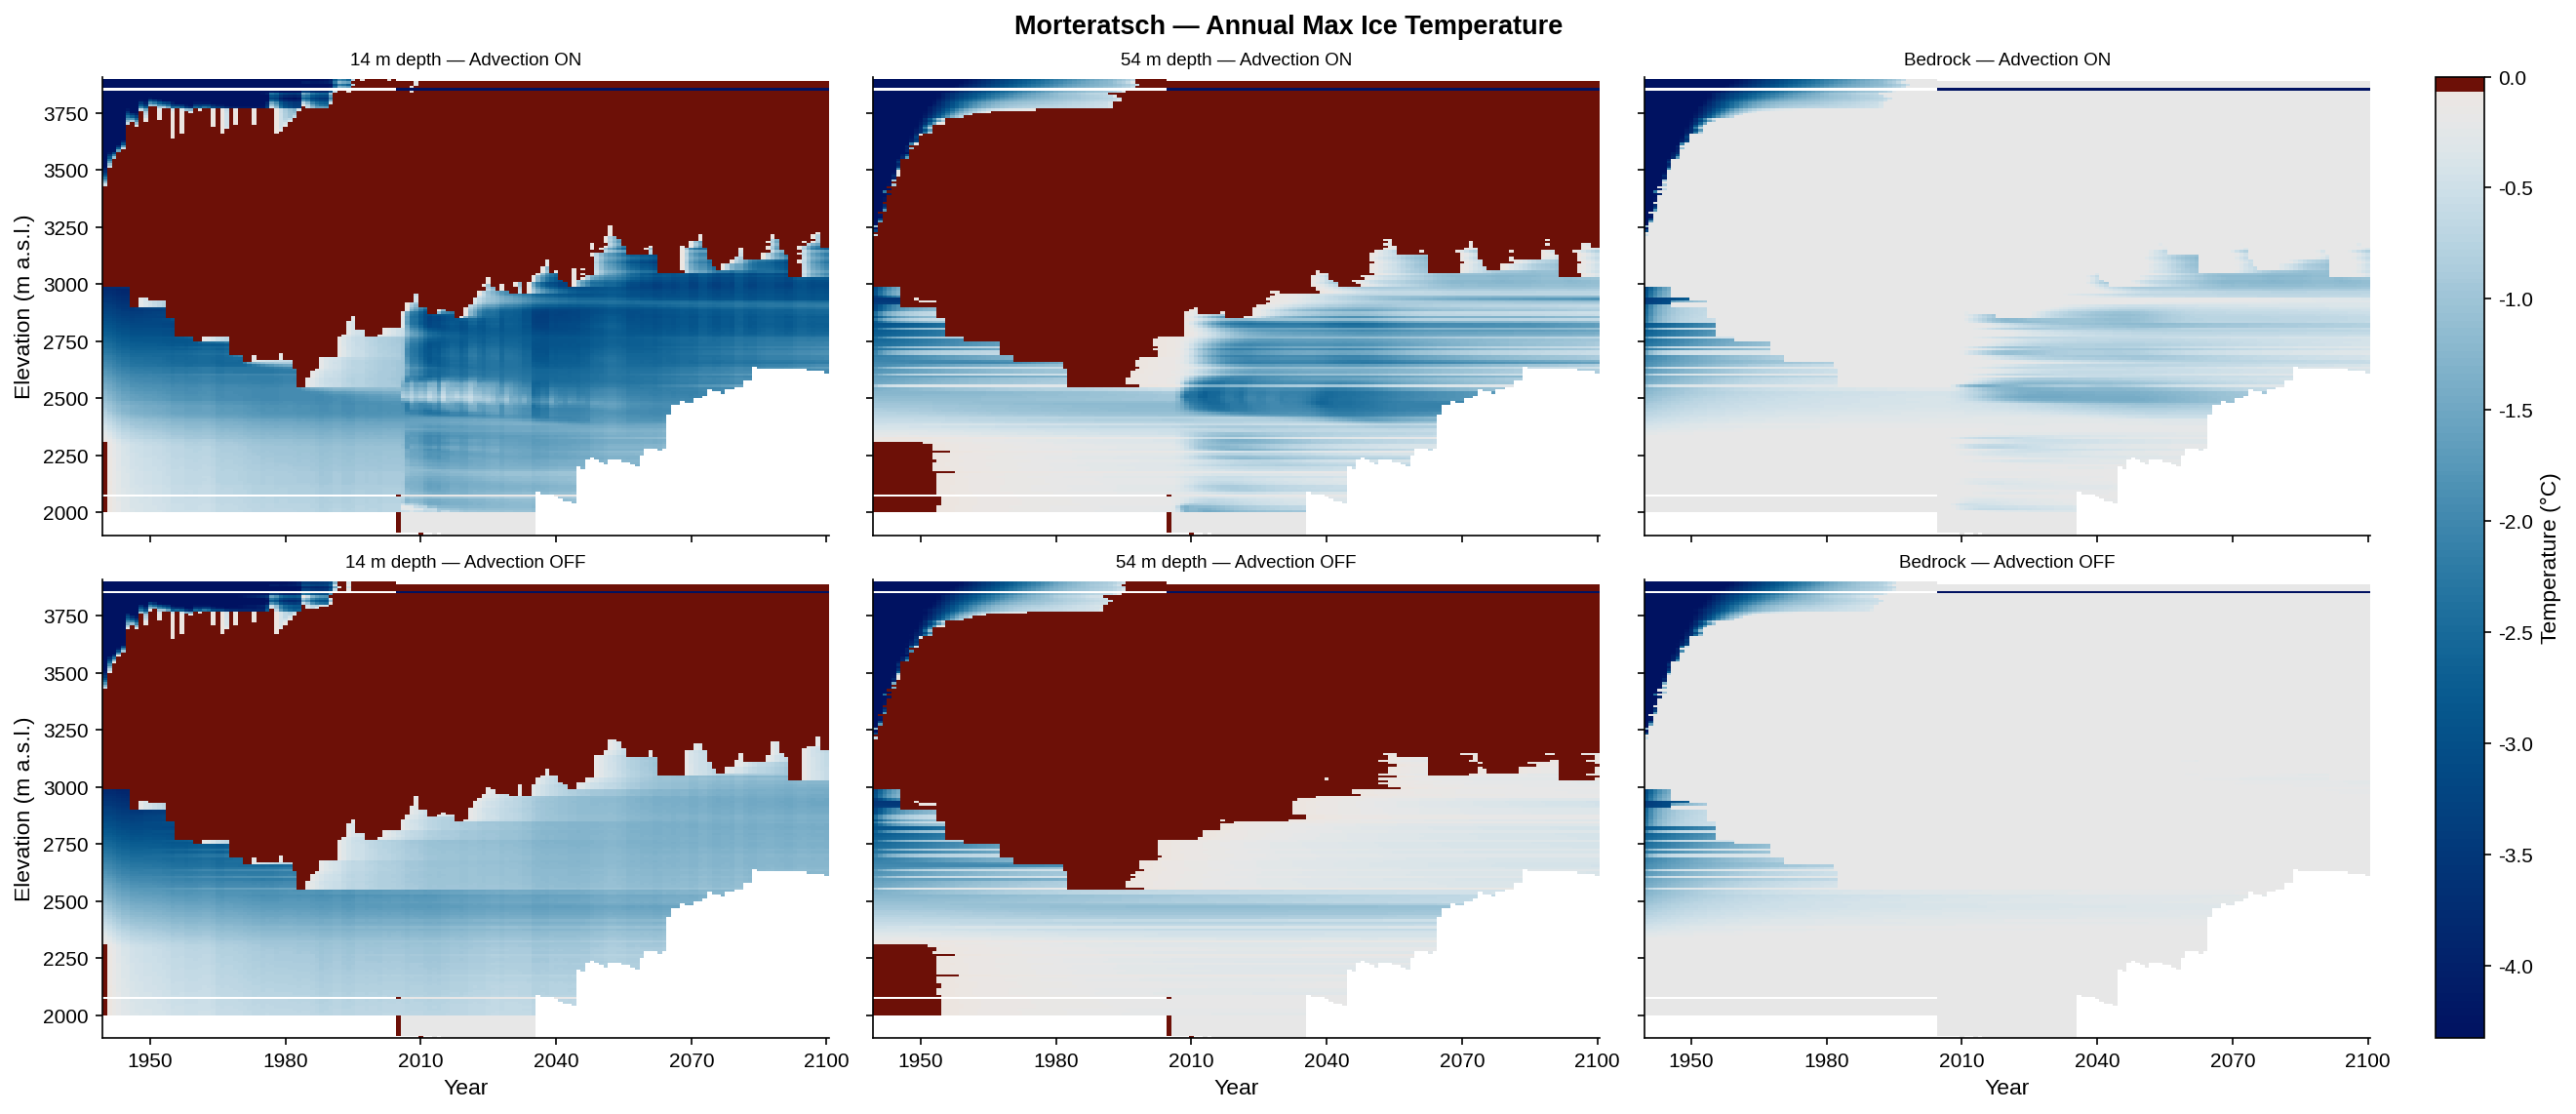

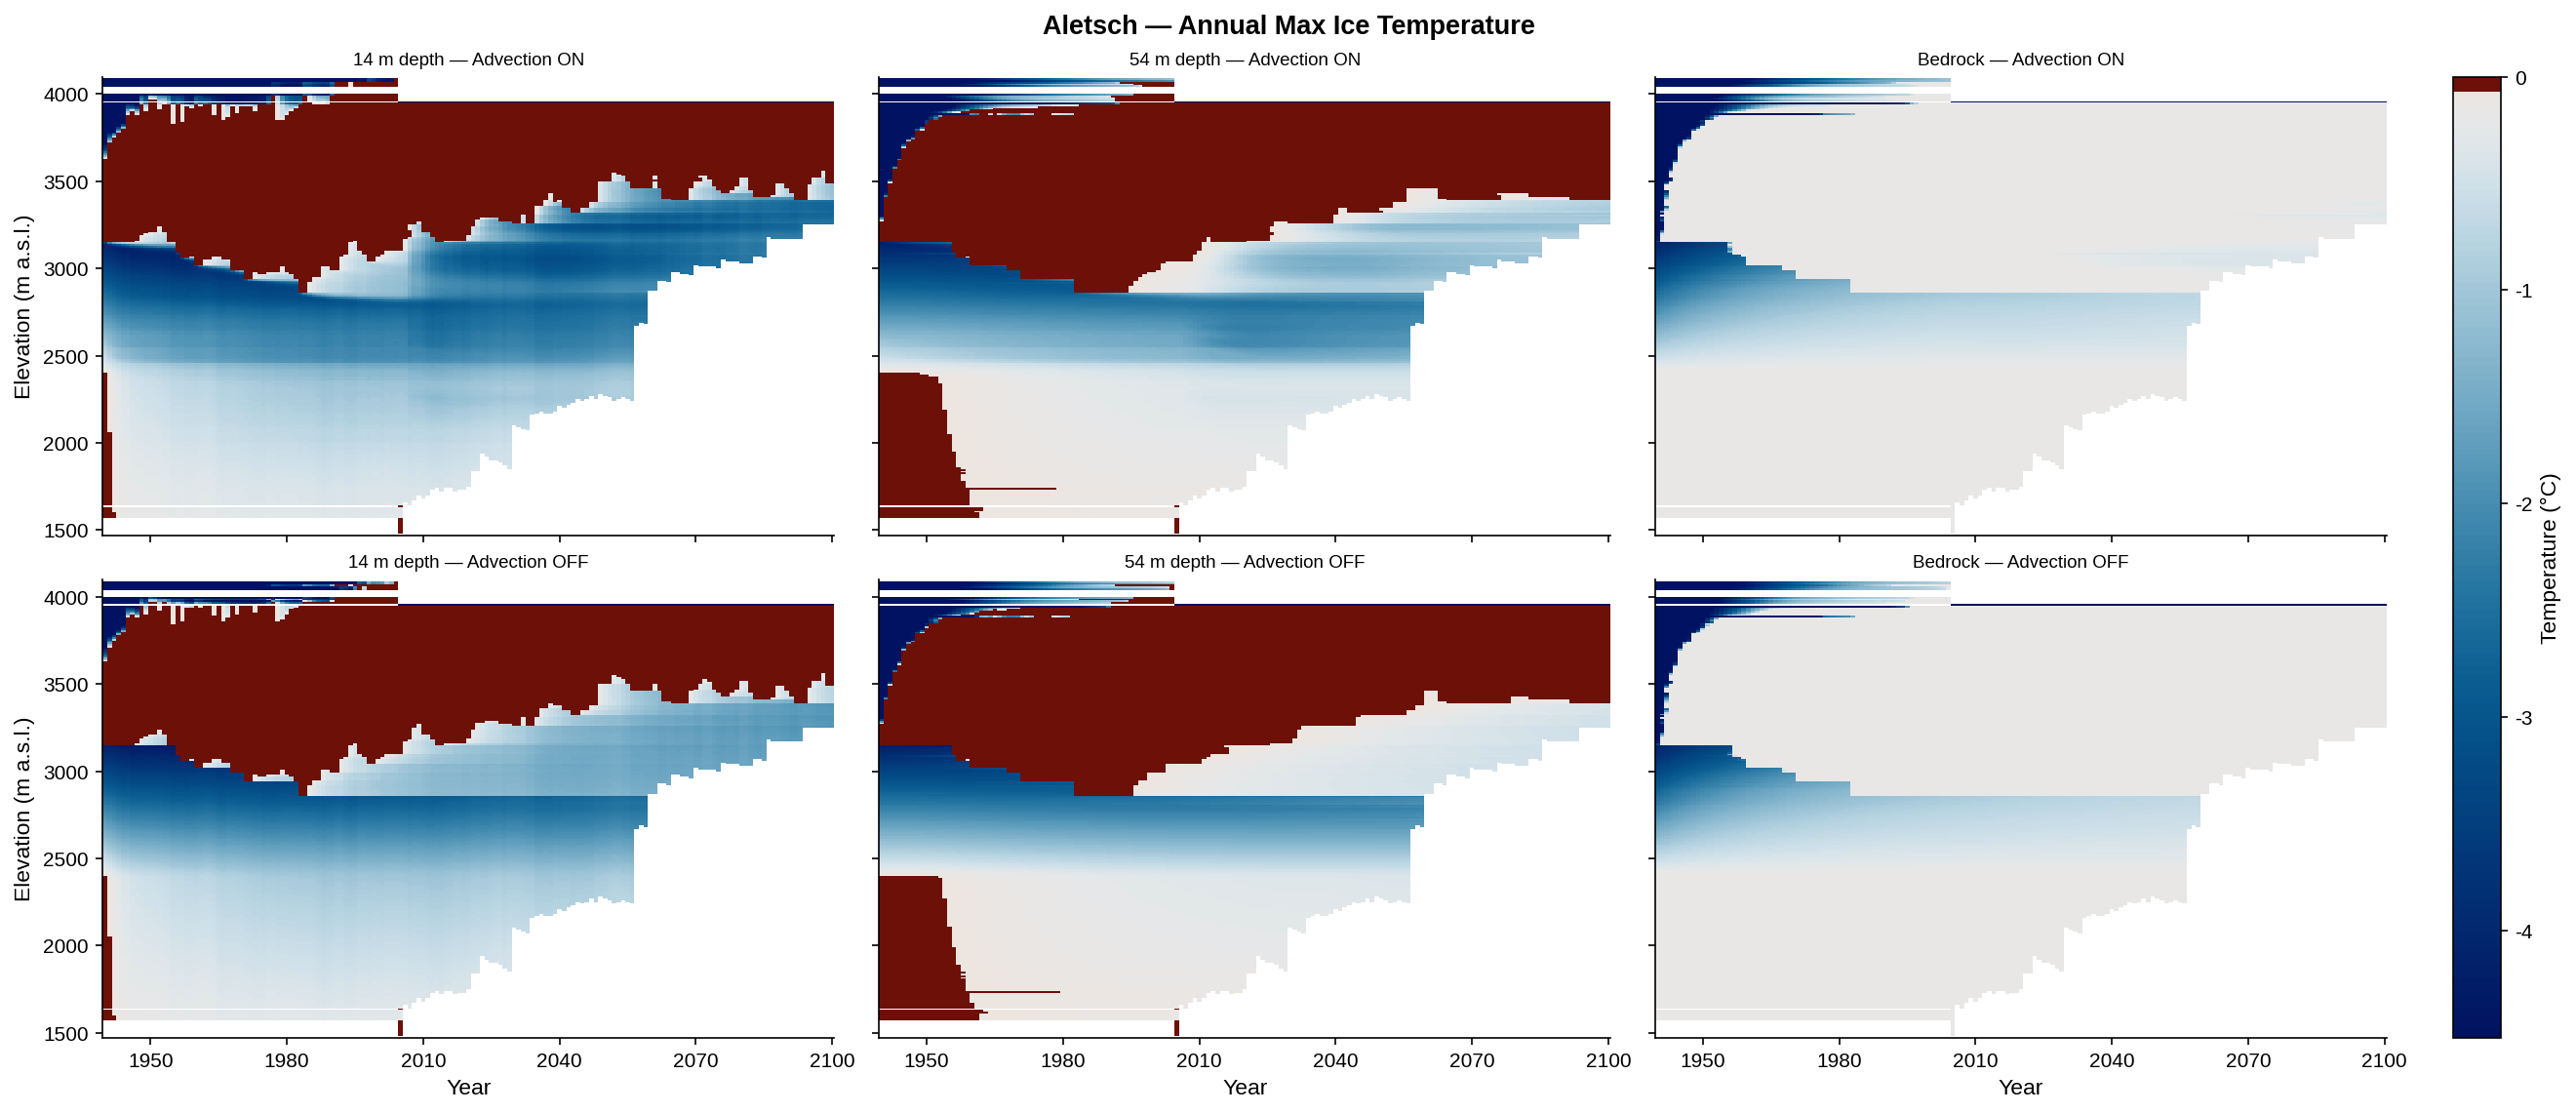

In [ ]:
DEPTH_KEYS   = ['10m', '50m', 'bedrock']
DEPTH_LABELS = {'10m': '14 m depth', '50m': '54 m depth', 'bedrock': 'Bedrock'}

for gid in glacier_ids:
    name = glacier_names[gid]

    # Shared colour limits
    all_vals = []
    for run in RUNS:
        d = runs_data[run].get(gid, {})
        for key in DEPTH_KEYS:
            if d.get(key) is not None:
                all_vals.extend(d[key][np.isfinite(d[key])].ravel())
    if not all_vals:
        continue
    vmin = min(np.percentile(all_vals, 2), -0.5)
    vmax = 0.0

    avail = [k for k in DEPTH_KEYS
              if any(runs_data[r].get(gid, {}).get(k) is not None for r in RUNS)]
    if not avail:
        continue

    # constrained_layout (instead of a trailing tight_layout()) reliably keeps
    # the shared colorbar outside the axes grid, on the right, regardless of
    # panel count.
    fig, axes = plt.subplots(2, len(avail),
                              figsize=(5.5 * len(avail) + 1.0, 7.5), sharey=True, sharex=True,
                              constrained_layout=True)
    if len(avail) == 1:
        axes = axes[:, np.newaxis]

    im_last = None
    for col, key in enumerate(avail):
        for row, run in enumerate(RUNS):
            ax = axes[row, col]
            d  = runs_data[run].get(gid, {})
            if d.get(key) is None:
                ax.set_visible(False)
                continue
            im = ax.pcolormesh(d['years'], d['elevs'], d[key],
                               cmap=CMAP_TEMP, vmin=vmin, vmax=vmax, shading='nearest')
            im_last = im
            ax.set_title(f"{DEPTH_LABELS[key]} — {RUN_LABELS[run]}", fontsize=9)
            ax.grid(False)
            if col == 0:
                ax.set_ylabel('Elevation (m a.s.l.)')
            if row == 1:
                ax.set_xlabel('Year')
                ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))

    if im_last is not None:
        fig.colorbar(im_last, ax=axes.ravel().tolist(), location='right',
                      fraction=0.025, pad=0.02, label='Temperature (°C)')
    fig.suptitle(f'{name} — Annual Max Ice Temperature', fontsize=13, fontweight='bold')
    plt.show()

---
## Section 2 — Advection Effect: ΔT = ADV − NO_ADV

**2a:** 2D maps of the advection effect over time at each depth level.  
**2b:** Time-mean ΔT as a function of elevation (with ±1σ shading).  

**Expected signal:**  
- Ablation zone → **negative ΔT** (cold ice advected down from accumulation zone)  
- Accumulation zone → ΔT ≈ 0 (horizontal advection effect small; vertical burial dominates)  
- Signal should be larger at deeper levels (14 m, 54 m) than at 2 m (annual signal dominates surface)

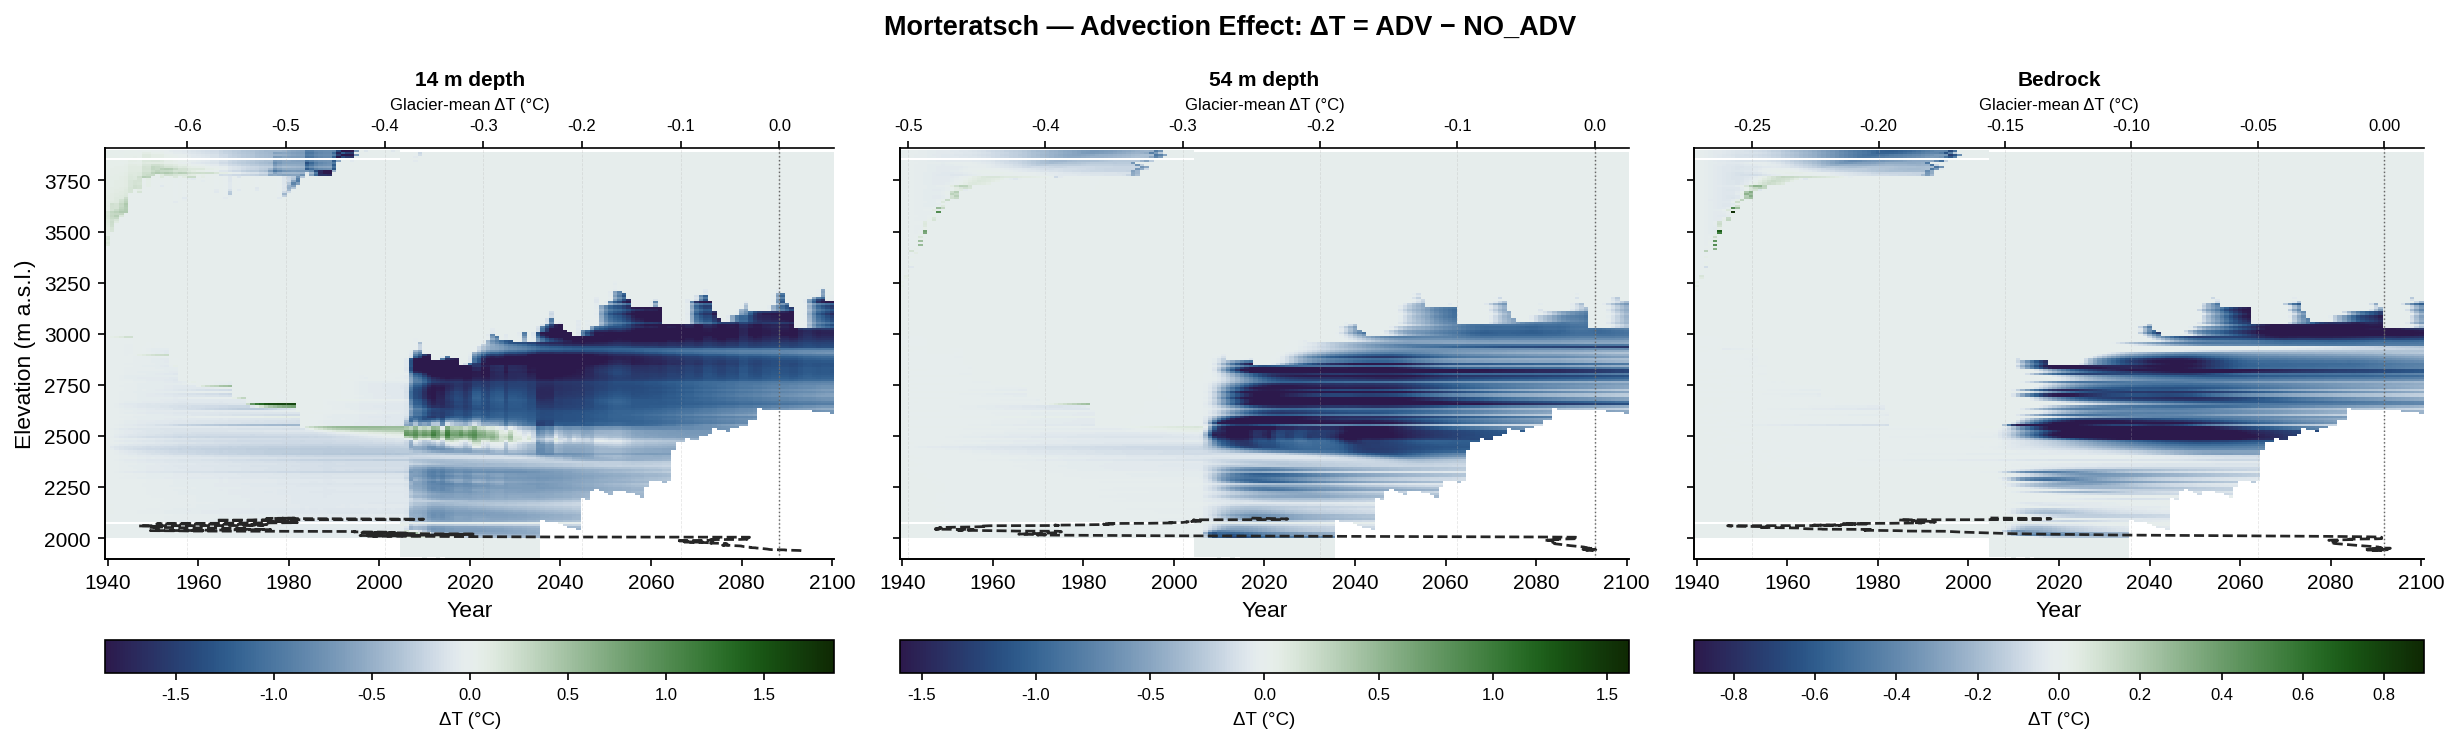


Morteratsch — mean advection effect (all bands × all years):
  14 m depth  : mean=-0.287 °C  min=-2.583 °C  max=+1.608 °C
  54 m depth  : mean=-0.210 °C  min=-2.250 °C  max=+0.866 °C
  Bedrock     : mean=-0.098 °C  min=-1.254 °C  max=+0.866 °C


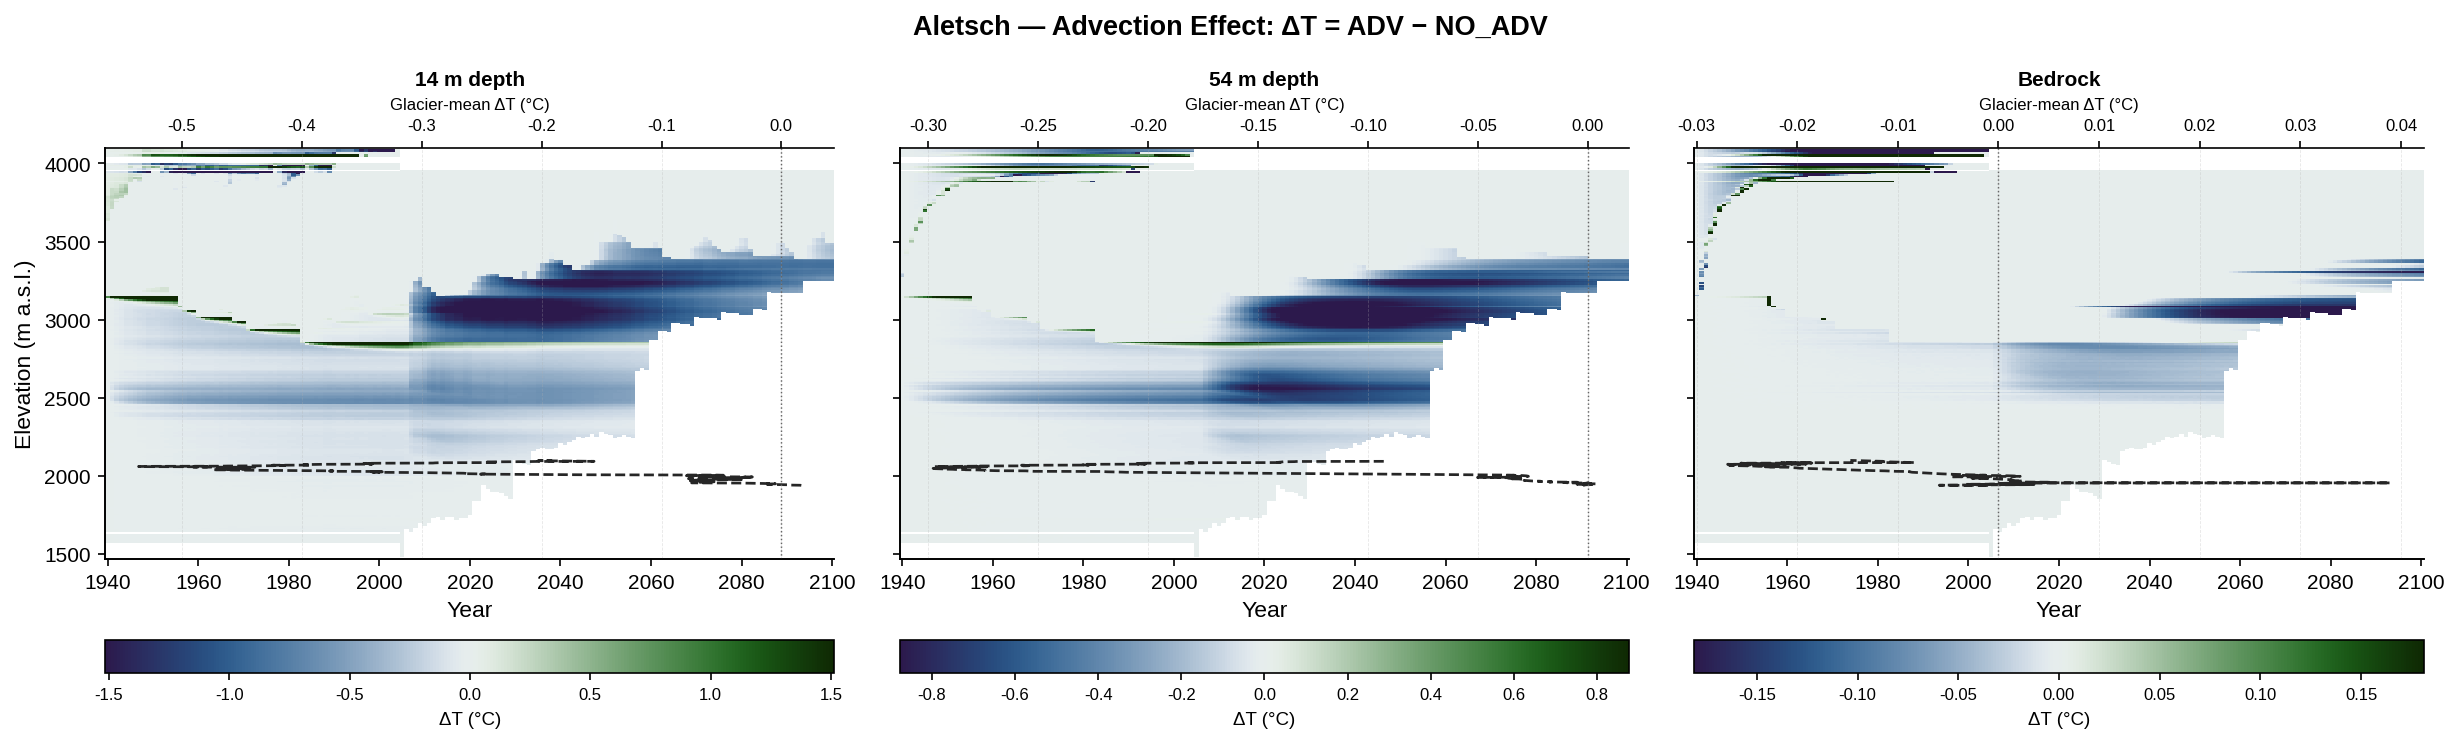


Aletsch — mean advection effect (all bands × all years):
  14 m depth  : mean=-0.186 °C  min=-4.437 °C  max=+4.524 °C
  54 m depth  : mean=-0.107 °C  min=-3.185 °C  max=+2.476 °C
  Bedrock     : mean=-0.006 °C  min=-1.186 °C  max=+3.087 °C


In [ ]:
for gid in glacier_ids:
    name  = glacier_names[gid]
    d_adv = runs_data['adv'].get(gid, {})
    d_noa = runs_data['no_adv'].get(gid, {})

    common_yrs, ia, ib = align_years(d_adv, d_noa)
    if common_yrs is None:
        print(f'{name}: cannot compute ΔT — missing years')
        continue

    avail = [k for k in DEPTH_KEYS
              if d_adv.get(k) is not None and d_noa.get(k) is not None]
    if not avail:
        print(f'{name}: cannot compute ΔT — data missing in one run')
        continue

    # 2a: 2D difference maps
    fig, axes = plt.subplots(1, len(avail), figsize=(5.5 * len(avail), 5), sharey=True)
    if len(avail) == 1:
        axes = [axes]

    for ax, key in zip(axes, avail):
        diff  = d_adv[key][:, ia] - d_noa[key][:, ib]
        elevs = d_adv['elevs']
        valid = diff[np.isfinite(diff)]
        if len(valid) == 0:
            ax.set_visible(False)
            continue
        vabs = max(np.percentile(np.abs(valid), 98), 0.05)

        im = ax.pcolormesh(common_yrs, elevs, diff,
                           cmap=CMAP_DIFF, vmin=-vabs, vmax=vabs, shading='nearest')
        cb = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.14, aspect=22)
        cb.set_label('ΔT (°C)', fontsize=9)
        cb.ax.tick_params(labelsize=8)

        # Glacier-mean ΔT per year as an overlaid line
        mean_dt = np.nanmean(diff, axis=0)
        ax2 = ax.twiny()
        ax2.plot(mean_dt, common_yrs, color='0.15', lw=1.3, ls='--')
        ax2.axvline(0, color='0.4', lw=0.7, ls=':')
        ax2.set_xlabel('Glacier-mean ΔT (°C)', fontsize=8)
        ax2.tick_params(labelsize=8)
        ax2.spines['top'].set_visible(True)

        ax.set_title(DEPTH_LABELS[key], fontsize=10, fontweight='bold')
        ax.set_xlabel('Year')
        ax.grid(False)

    axes[0].set_ylabel('Elevation (m a.s.l.)')
    fig.suptitle(f'{name} — Advection Effect: ΔT = ADV − NO_ADV',
                  fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

    # Scalar summary
    print(f'\n{name} — mean advection effect (all bands × all years):')
    for key in avail:
        diff = d_adv[key][:, ia] - d_noa[key][:, ib]
        print(f'  {DEPTH_LABELS[key]:12s}: mean={np.nanmean(diff):+.3f} °C  '
              f'min={np.nanmin(diff):+.3f} °C  max={np.nanmax(diff):+.3f} °C')

/tmp/ipykernel_387189/3614990819.py:23: RuntimeWarning: Mean of empty slice
  mean_dt = np.nanmean(diff, axis=1)
/scratch_net/vierzack04/jabeer/conda_envs/glogemflow_development/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


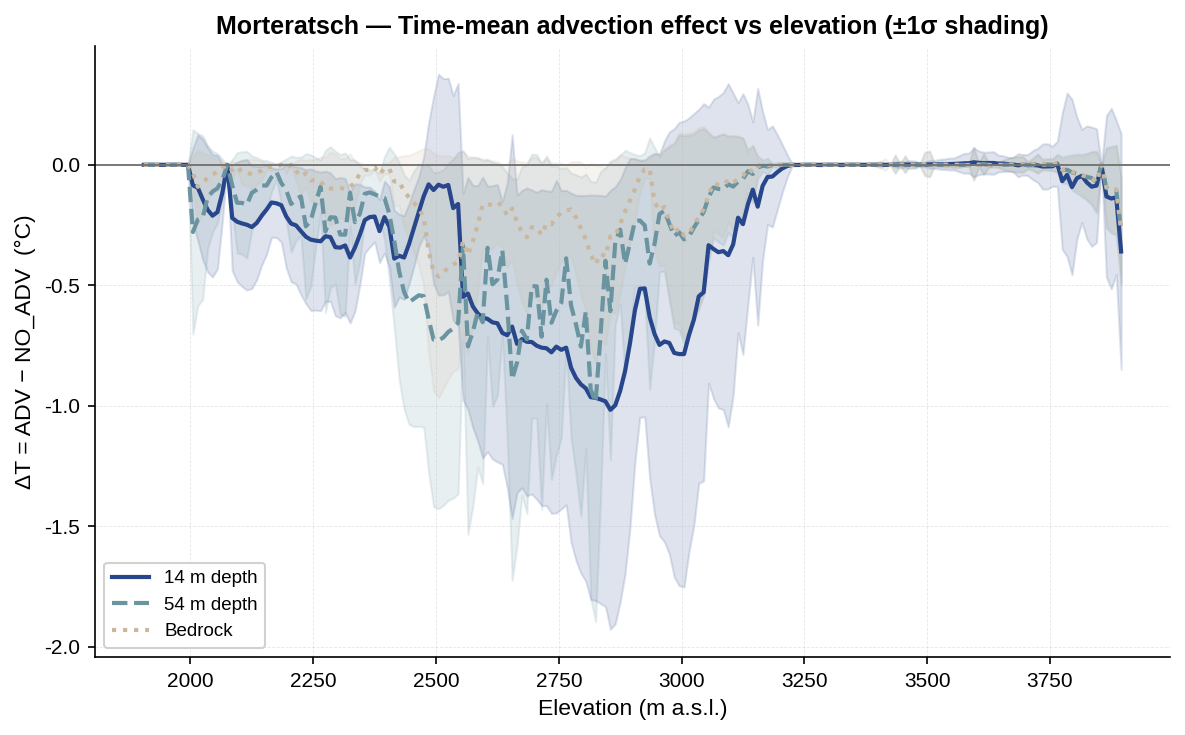

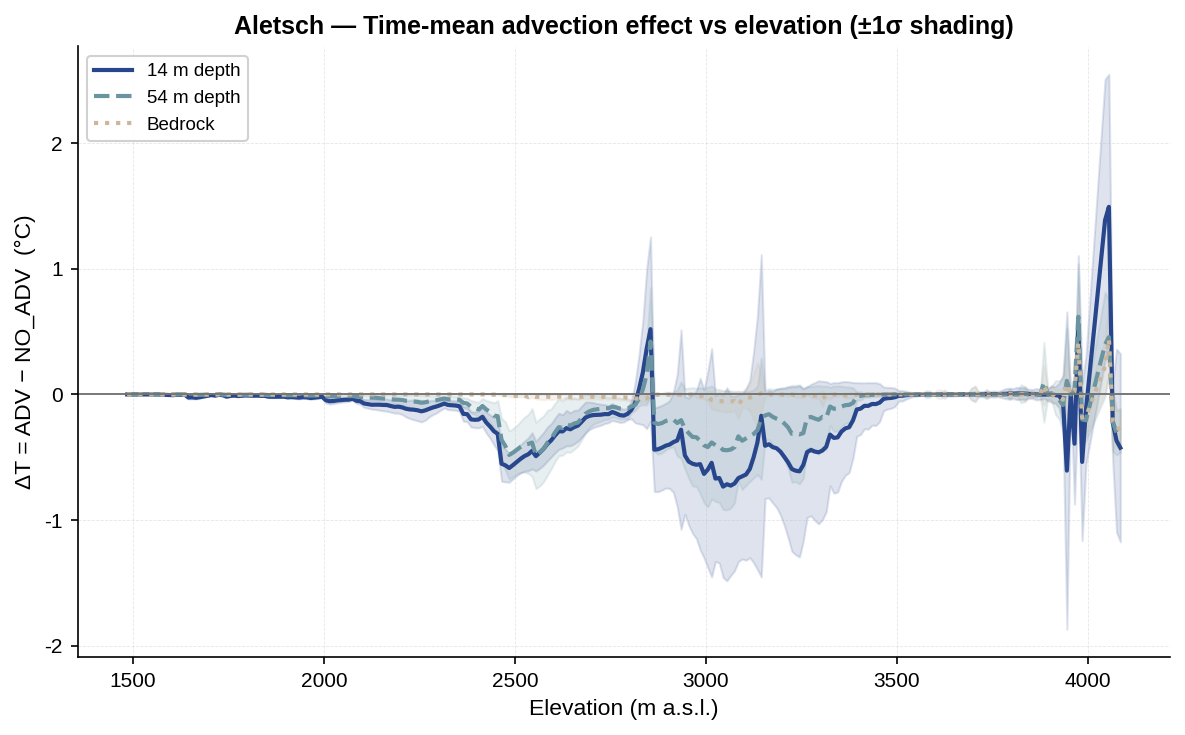

In [ ]:
# 2b: Time-mean ΔT vs elevation
for gid in glacier_ids:
    name  = glacier_names[gid]
    d_adv = runs_data['adv'].get(gid, {})
    d_noa = runs_data['no_adv'].get(gid, {})

    common_yrs, ia, ib = align_years(d_adv, d_noa)
    if common_yrs is None:
        continue

    fig, ax = plt.subplots(figsize=(8, 5))
    lstyles = {'10m': '-', '50m': '--', 'bedrock': ':'}
    depth_colors = {
        '10m':     cmc.lapaz(0.20),
        '50m':     cmc.lapaz(0.55),
        'bedrock': cmc.lapaz(0.80),
    }

    for key in DEPTH_KEYS:
        if d_adv.get(key) is None or d_noa.get(key) is None:
            continue
        diff    = d_adv[key][:, ia] - d_noa[key][:, ib]
        mean_dt = np.nanmean(diff, axis=1)
        std_dt  = np.nanstd(diff,  axis=1)
        elevs   = d_adv['elevs']
        valid   = np.isfinite(mean_dt)
        col     = depth_colors[key]

        ax.plot(elevs[valid], mean_dt[valid], color=col, lw=2.0,
                ls=lstyles[key], label=DEPTH_LABELS[key])
        ax.fill_between(elevs[valid],
                         mean_dt[valid] - std_dt[valid],
                         mean_dt[valid] + std_dt[valid],
                         alpha=0.15, color=col)

    ax.axhline(0, color='0.45', lw=0.9, ls='-')
    ax.set_xlabel('Elevation (m a.s.l.)', fontsize=11)
    ax.set_ylabel('ΔT = ADV − NO_ADV  (°C)', fontsize=11)
    ax.set_title(f'{name} — Time-mean advection effect vs elevation (±1σ shading)',
                  fontsize=12, fontweight='bold')
    ax.legend()
    fig.tight_layout()
    plt.show()

---
## Section 3 — Ice-Temperature Cross-Section: Elevation × Depth

2D temperature field for a chosen year.  
Three panels per glacier: ADV, NO_ADV, and their difference.

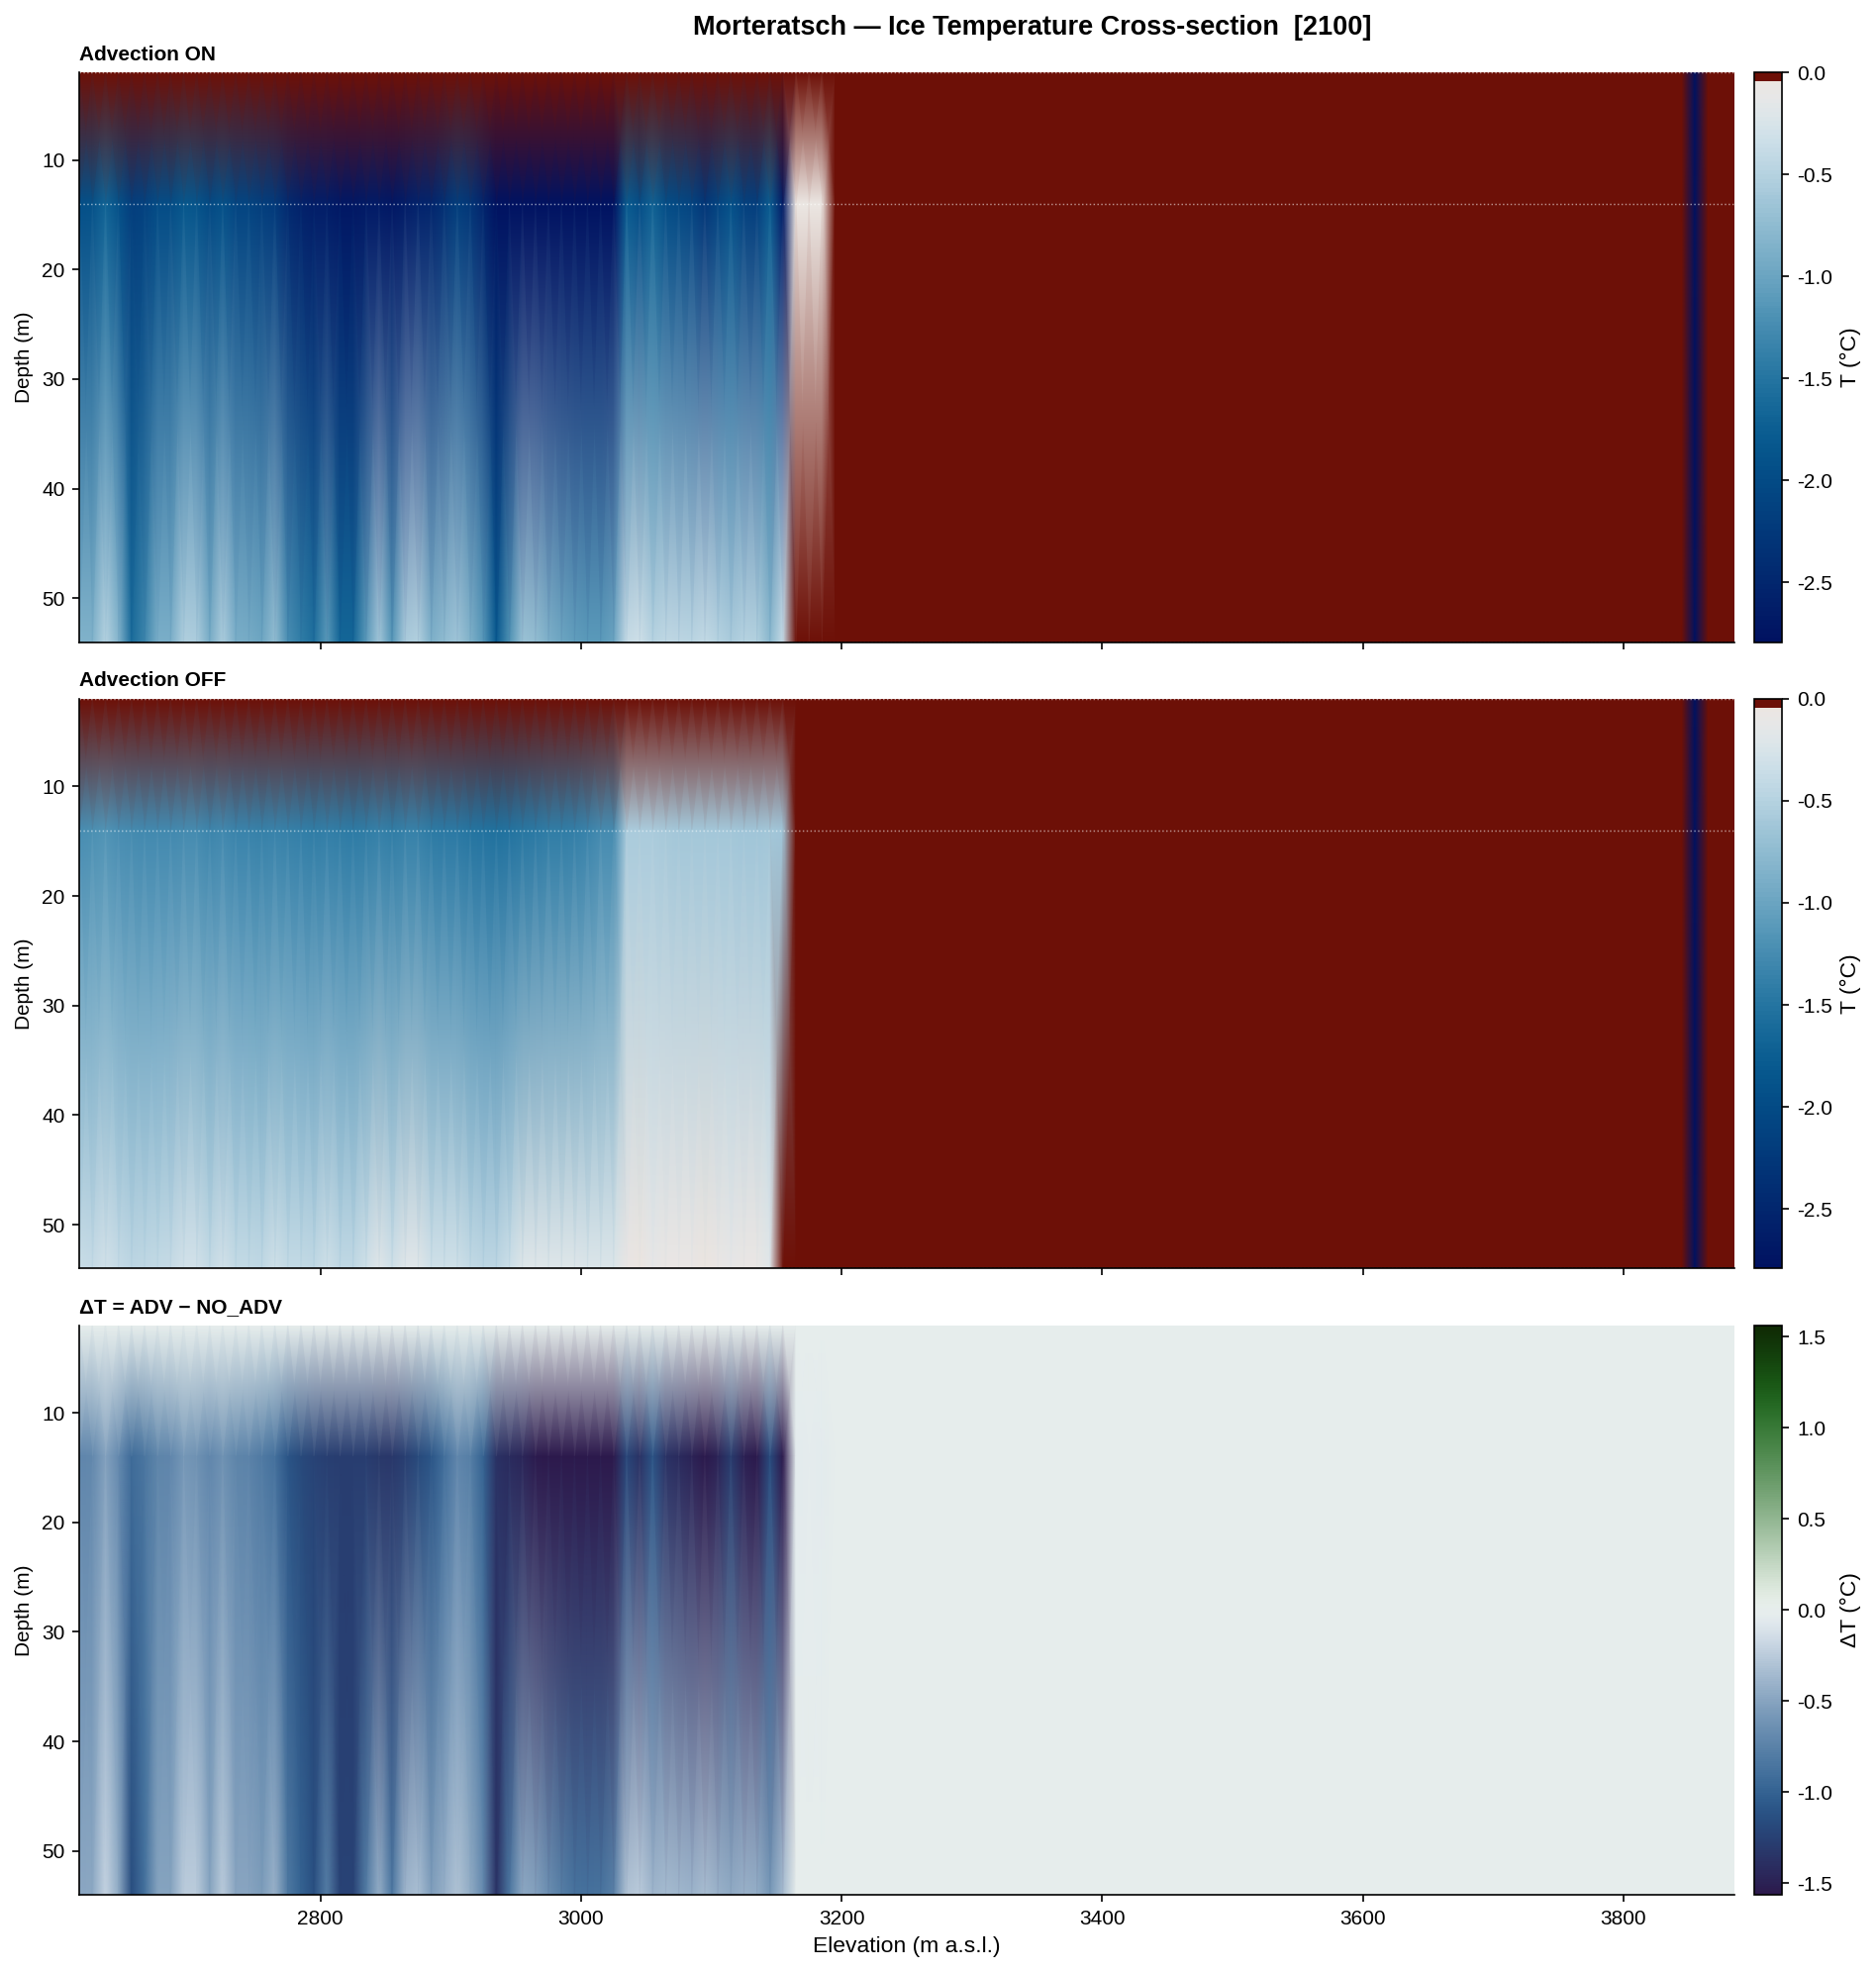

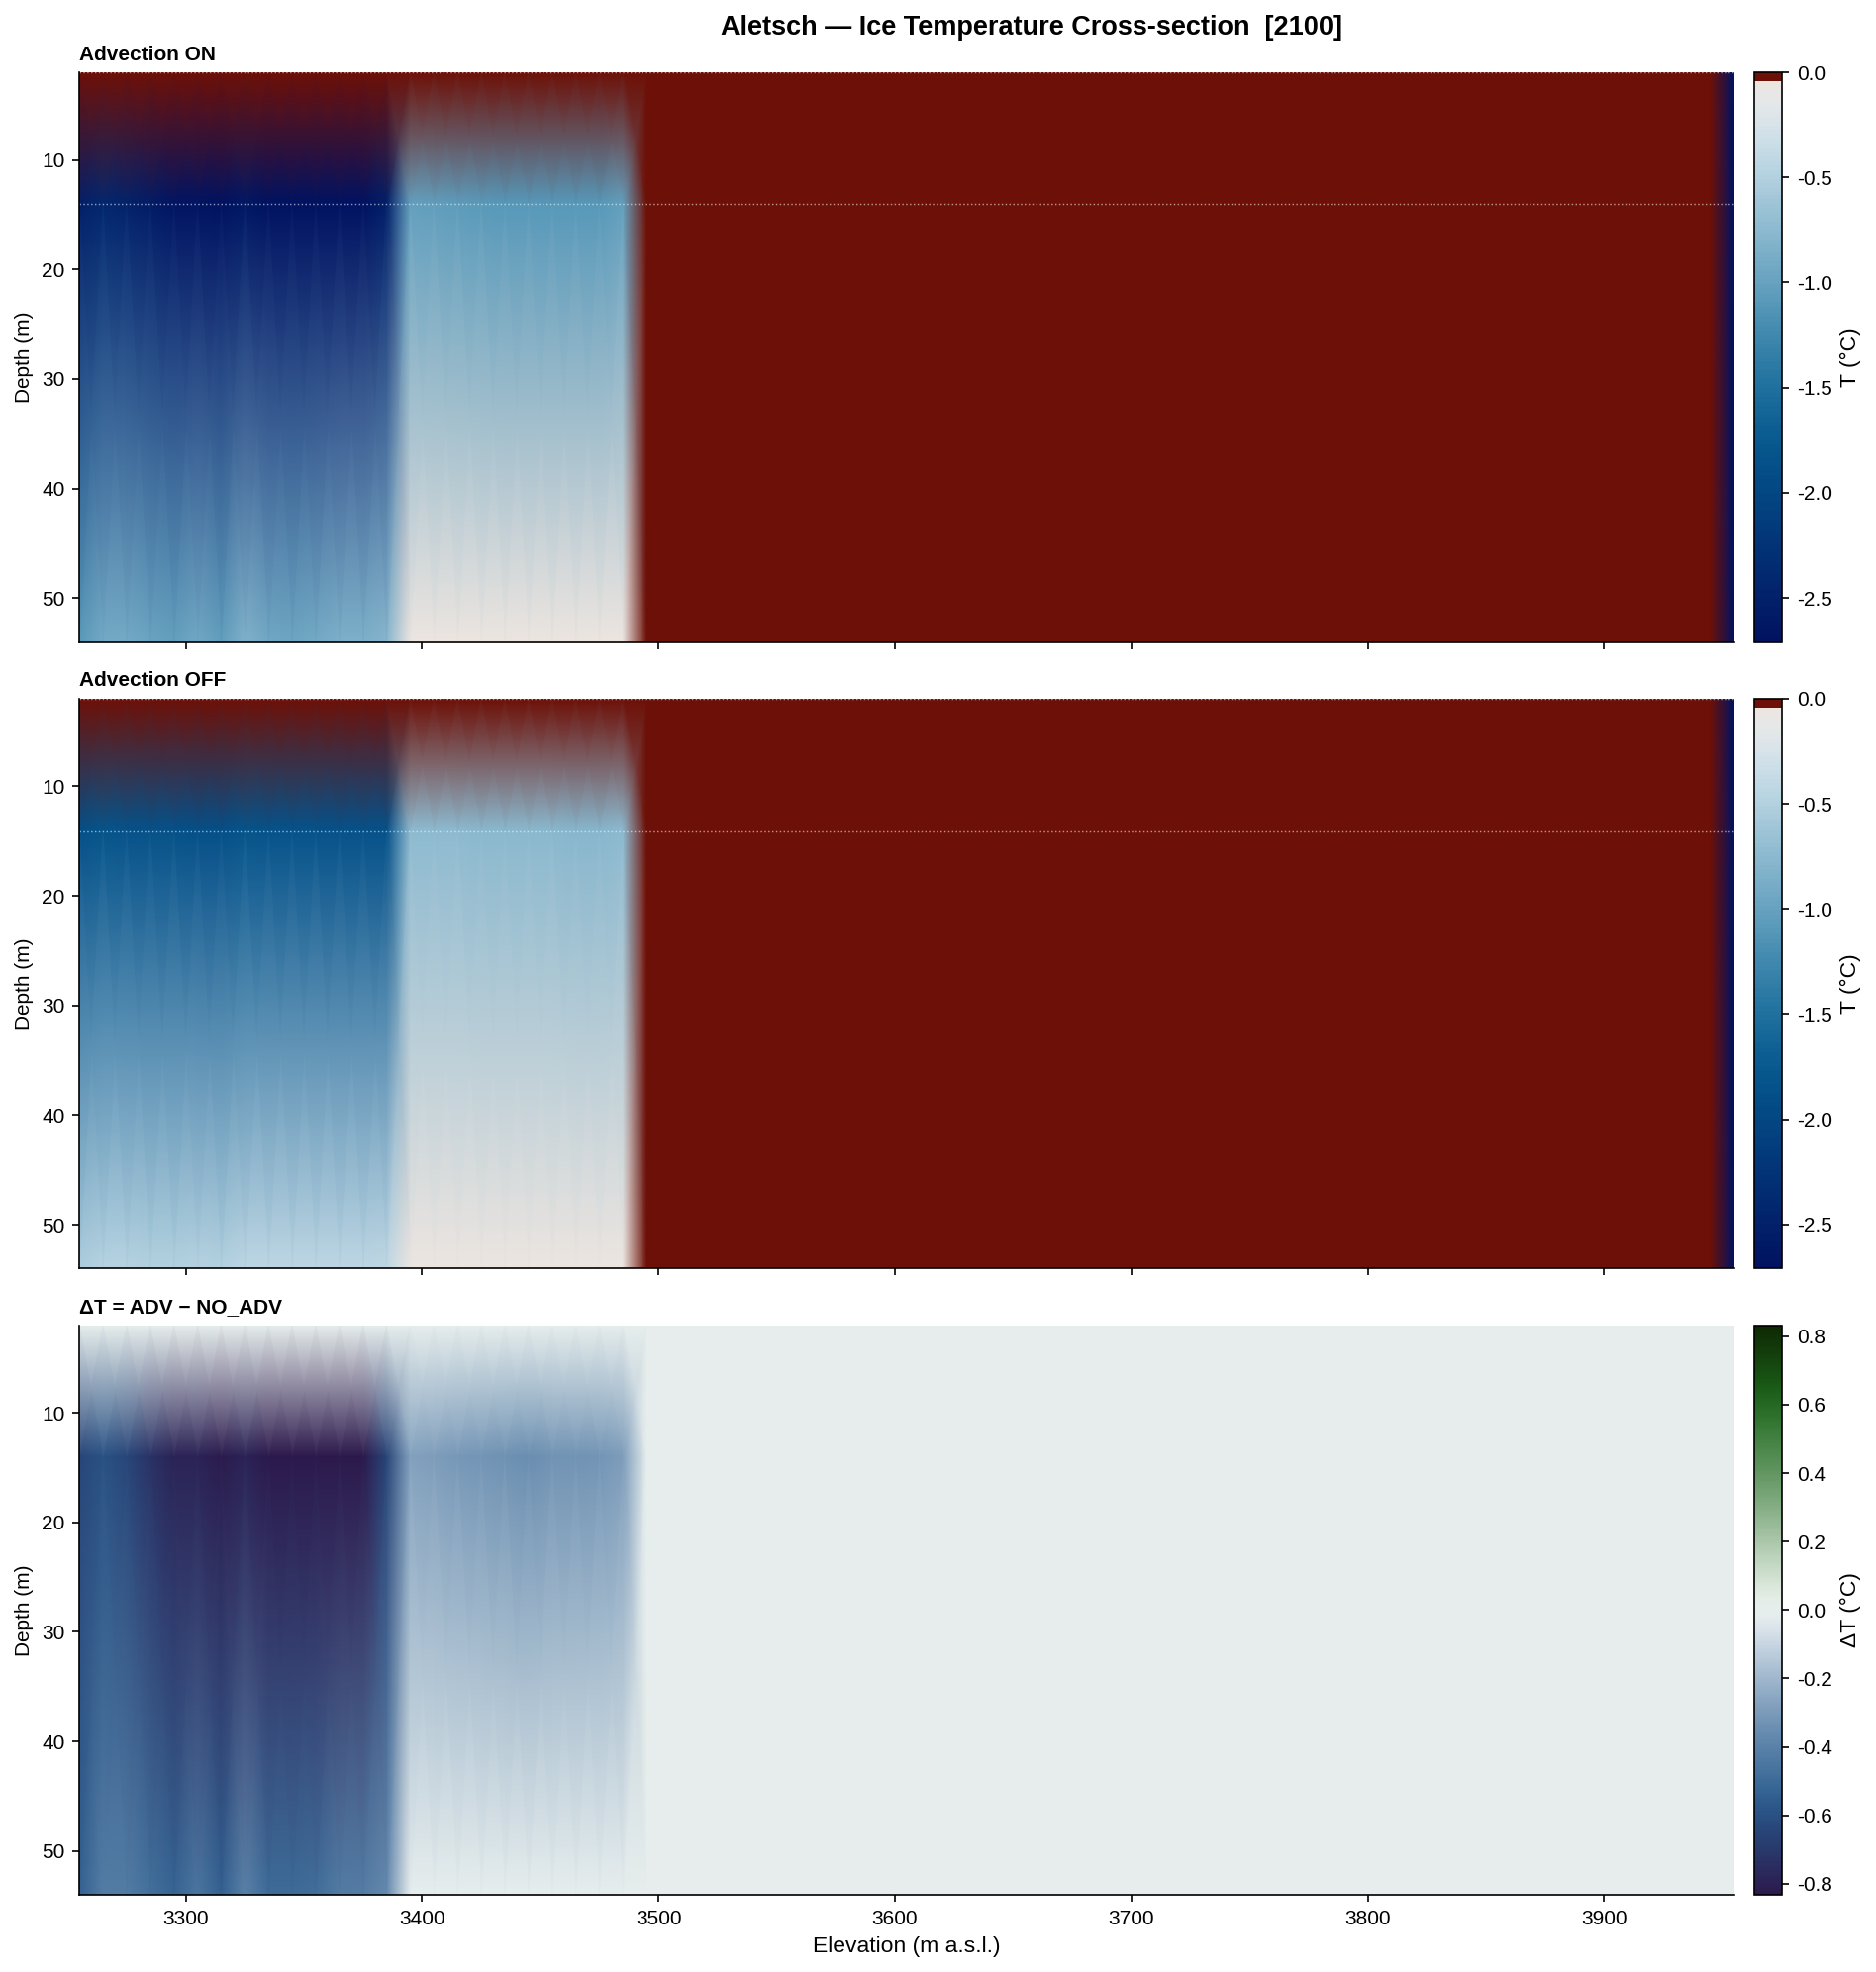

In [ ]:
CS_KEYS  = ['1m', '10m', '50m']
CS_DEPTH = [2.0, 14.0, 54.0]

def build_cs(d, year):
    """Extract elevation × depth temperature matrix for one year."""
    yrs = d.get('years')
    if yrs is None:
        return None, None, None
    yi    = min(np.searchsorted(yrs, year), len(yrs) - 1)
    elevs = d['elevs']
    cols  = [
        d[k][:, yi].copy() if d.get(k) is not None else np.full(len(elevs), np.nan)
        for k in CS_KEYS
    ]
    T     = np.column_stack(cols)   # (nb, 3)
    valid = np.any(np.isfinite(T), axis=1)
    return elevs[valid], np.array(CS_DEPTH), T[valid]


def pick_default_year(d):
    """Last available year for a run dict, or None if no years are available."""
    yrs = d.get('years') if d else None
    return None if yrs is None or len(yrs) == 0 else yrs[-1]


for gid in glacier_ids:
    name = glacier_names[gid]
    if PROFILE_YEAR is not None:
        year = PROFILE_YEAR
    else:
        year = pick_default_year(runs_data['adv'].get(gid, {}))
        if year is None:
            year = pick_default_year(runs_data['no_adv'].get(gid, {}))
    if year is None:
        print(f'{name}: no years available in either run — skipping cross-section')
        continue

    d_adv = runs_data['adv'].get(gid, {})
    d_noa = runs_data['no_adv'].get(gid, {})
    elevs_a, depths, T_a = build_cs(d_adv, year)
    elevs_n, depths, T_n = build_cs(d_noa, year)

    if elevs_a is None and elevs_n is None:
        continue

    # Shared temperature colour limits
    all_T = [v for v in [T_a, T_n] if v is not None]
    vals  = np.concatenate([t[np.isfinite(t)] for t in all_T])
    vmin  = min(np.percentile(vals, 2), -0.3) if len(vals) else -10
    vmax  = 0.0

    # Difference on common elevation grid
    diff_ready = elevs_a is not None and elevs_n is not None
    n_panels = 2 + int(diff_ready)

    # Wide panels: elevation (x) spans the full glacier (~2000 m range) and
    # needs the resolution, while depth (y) only spans 0-54 m -- a square or
    # tall panel would compress the more information-dense x axis.
    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 4.5 * n_panels), sharex=True)

    for ax, elevs_cs, T_cs, lbl in zip(
        axes[:2],
        [elevs_a, elevs_n],
        [T_a, T_n],
        ['Advection ON', 'Advection OFF'],
    ):
        if elevs_cs is None:
            ax.set_visible(False)
            continue
        X  = np.tile(elevs_cs, (len(depths), 1))
        Y  = np.tile(depths[:, None], (1, len(elevs_cs)))
        pc = ax.pcolormesh(X, Y, T_cs.T, cmap=CMAP_TEMP,
                           vmin=vmin, vmax=vmax, shading='gouraud')
        fig.colorbar(pc, ax=ax, pad=0.01, label='T (°C)')
        ax.invert_yaxis()
        ax.set_title(lbl, fontsize=10, fontweight='bold', loc='left')
        ax.set_ylabel('Depth (m)', fontsize=10)
        ax.grid(False)
        for dep in CS_DEPTH:
            ax.axhline(dep, color='white', lw=0.7, ls=':', alpha=0.55)

    if diff_ready:
        ax_d = axes[2]
        common_e = np.intersect1d(elevs_a, elevs_n)
        ia2, ib2 = np.searchsorted(elevs_a, common_e), np.searchsorted(elevs_n, common_e)
        diff = T_a[ia2] - T_n[ib2]
        dvals = diff[np.isfinite(diff)]
        vabs  = max(np.percentile(np.abs(dvals), 98), 0.05) if len(dvals) else 0.5
        X2 = np.tile(common_e, (len(depths), 1))
        Y2 = np.tile(depths[:, None], (1, len(common_e)))
        pc2 = ax_d.pcolormesh(X2, Y2, diff.T, cmap=CMAP_DIFF,
                               vmin=-vabs, vmax=vabs, shading='gouraud')
        fig.colorbar(pc2, ax=ax_d, pad=0.01, label='ΔT (°C)')
        ax_d.invert_yaxis()
        ax_d.set_title('ΔT = ADV − NO_ADV', fontsize=10, fontweight='bold', loc='left')
        ax_d.set_ylabel('Depth (m)', fontsize=10)
        ax_d.grid(False)

    axes[-1].set_xlabel('Elevation (m a.s.l.)', fontsize=11)
    fig.suptitle(f'{name} — Ice Temperature Cross-section  [{year}]',
                  fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

---
## Section 3b — Glacier Cross-Section: Real Geometry Colored by Ice Temperature

The actual along-flow wedge shape (bed → surface, x = distance from terminus in m,
y = elevation in m a.s.l.) for each requested year, filled with ice temperature
interpolated by depth below the local surface. Built from the flowline geometry
history (`flowgrid_<id>_flow.sav`, written by `save_geometry_output.pro` when
`write_geometry_output='y'`) combined with the per-band depth samples
(2 m / 14 m / 54 m / bedrock) already loaded above.

**Requires a re-run with `write_geometry_output='y'`** — this is not in the
existing `.dat` output, so this section will print a message and skip cleanly
if the `.sav` files aren't found yet.

In [ ]:
from icetemp.io import load_flowgrid

geometry_data = {run: {} for run in RUNS}
has_geometry = False
for run in RUNS:
    gdir = GEOMETRY_DIRS[run]
    if not gdir.exists():
        continue
    for gid in glacier_ids:
        sav = load_flowgrid(gid, gdir)
        if sav is not None:
            geometry_data[run][gid] = sav
            has_geometry = True

if not has_geometry:
    print('No flowgrid_*.sav files found in either run.\n'
          'Re-run with write_geometry_output=\'y\' in config.pro to enable Section 3b.')
else:
    for run in RUNS:
        found = list(geometry_data[run].keys())
        print(f'{RUN_LABELS[run]:18s}: geometry for {[glacier_names.get(g, g) for g in found]}')

In [ ]:
from icetemp.plots import build_glacier_cross_section

CROSS_SECTION_BOX_ASPECT = 0.8

if has_geometry:
    for gid in glacier_ids:
        name = glacier_names[gid]

        results = {}
        x_lo, x_hi, z_lo, z_hi = np.inf, -np.inf, np.inf, -np.inf
        all_T = []
        for run in RUNS:
            d, sav = runs_data[run].get(gid, {}), geometry_data[run].get(gid)
            if sav is None:
                continue
            for year in CROSS_SECTION_YEARS:
                res = build_glacier_cross_section(d, sav, year)
                results[(run, year)] = res
                if res is not None:
                    X, Z, T = res
                    x_lo, x_hi = min(x_lo, X.min()), max(x_hi, X.max())
                    z_lo, z_hi = min(z_lo, Z.min()), max(z_hi, Z.max())
                    all_T.append(T[np.isfinite(T)])

        if not all_T:
            print(f'{name}: no cross-section data available for the requested years')
            continue
        vmin = min(np.percentile(np.concatenate(all_T), 2), -0.3)
        vmax = 0.0
        x_pad = 0.05 * (x_hi - x_lo)
        z_pad = 0.08 * (z_hi - z_lo)

        n_runs_avail = sum(geometry_data[run].get(gid) is not None for run in RUNS)
        fig, axes = plt.subplots(n_runs_avail, len(CROSS_SECTION_YEARS),
                                  figsize=(3.4 * len(CROSS_SECTION_YEARS), 3.4 * CROSS_SECTION_BOX_ASPECT * n_runs_avail),
                                  sharey=True, constrained_layout=True)
        axes = np.atleast_2d(axes)
        if axes.shape[0] == 1 and n_runs_avail == 1:
            axes = axes.reshape(1, -1)

        im_last = None
        row = 0
        for run in RUNS:
            sav = geometry_data[run].get(gid)
            if sav is None:
                continue
            for col, year in enumerate(CROSS_SECTION_YEARS):
                ax = axes[row, col]
                res = results.get((run, year))
                if res is None:
                    ax.set_visible(False)
                    continue
                X, Z, T = res
                ax.fill_between(sav['dist_dx'] / 1000.0, sav['bed_dx'],
                                z_lo - z_pad, color='0.88', zorder=0)
                im = ax.pcolormesh(X / 1000.0, Z, T, cmap=CMAP_TEMP, vmin=vmin, vmax=vmax, shading='gouraud')
                im_last = im
                ax.plot(sav['dist_dx'] / 1000.0, sav['bed_dx'], color='0.35', lw=1.2)
                ax.set_xlim((x_lo - x_pad) / 1000.0, (x_hi + x_pad) / 1000.0)
                ax.set_ylim(z_lo - z_pad, z_hi + z_pad)
                ax.set_box_aspect(CROSS_SECTION_BOX_ASPECT)
                ax.set_title(f'{RUN_LABELS[run]} — {year}', fontsize=9)
                ax.grid(True)
                ax.tick_params(axis='y', labelleft=True)
                if col == 0:
                    ax.set_ylabel('Elevation (m a.s.l.)')
                if row == n_runs_avail - 1:
                    ax.set_xlabel('Distance from terminus (km)')
            row += 1

        if im_last is not None:
            fig.colorbar(im_last, ax=axes.ravel().tolist(), location='right',
                          fraction=0.02, pad=0.02, label='Temperature (°C)')
        fig.suptitle(f'{name} — Glacier Cross-Section by Ice Temperature', fontsize=13, fontweight='bold')
        plt.show()

---
## Section 4 — Temperature Evolution at Key Elevations

Both runs plotted together at four elevation positions.  
Solid = ADV, dashed = NO_ADV. The gap between lines is the advection effect.

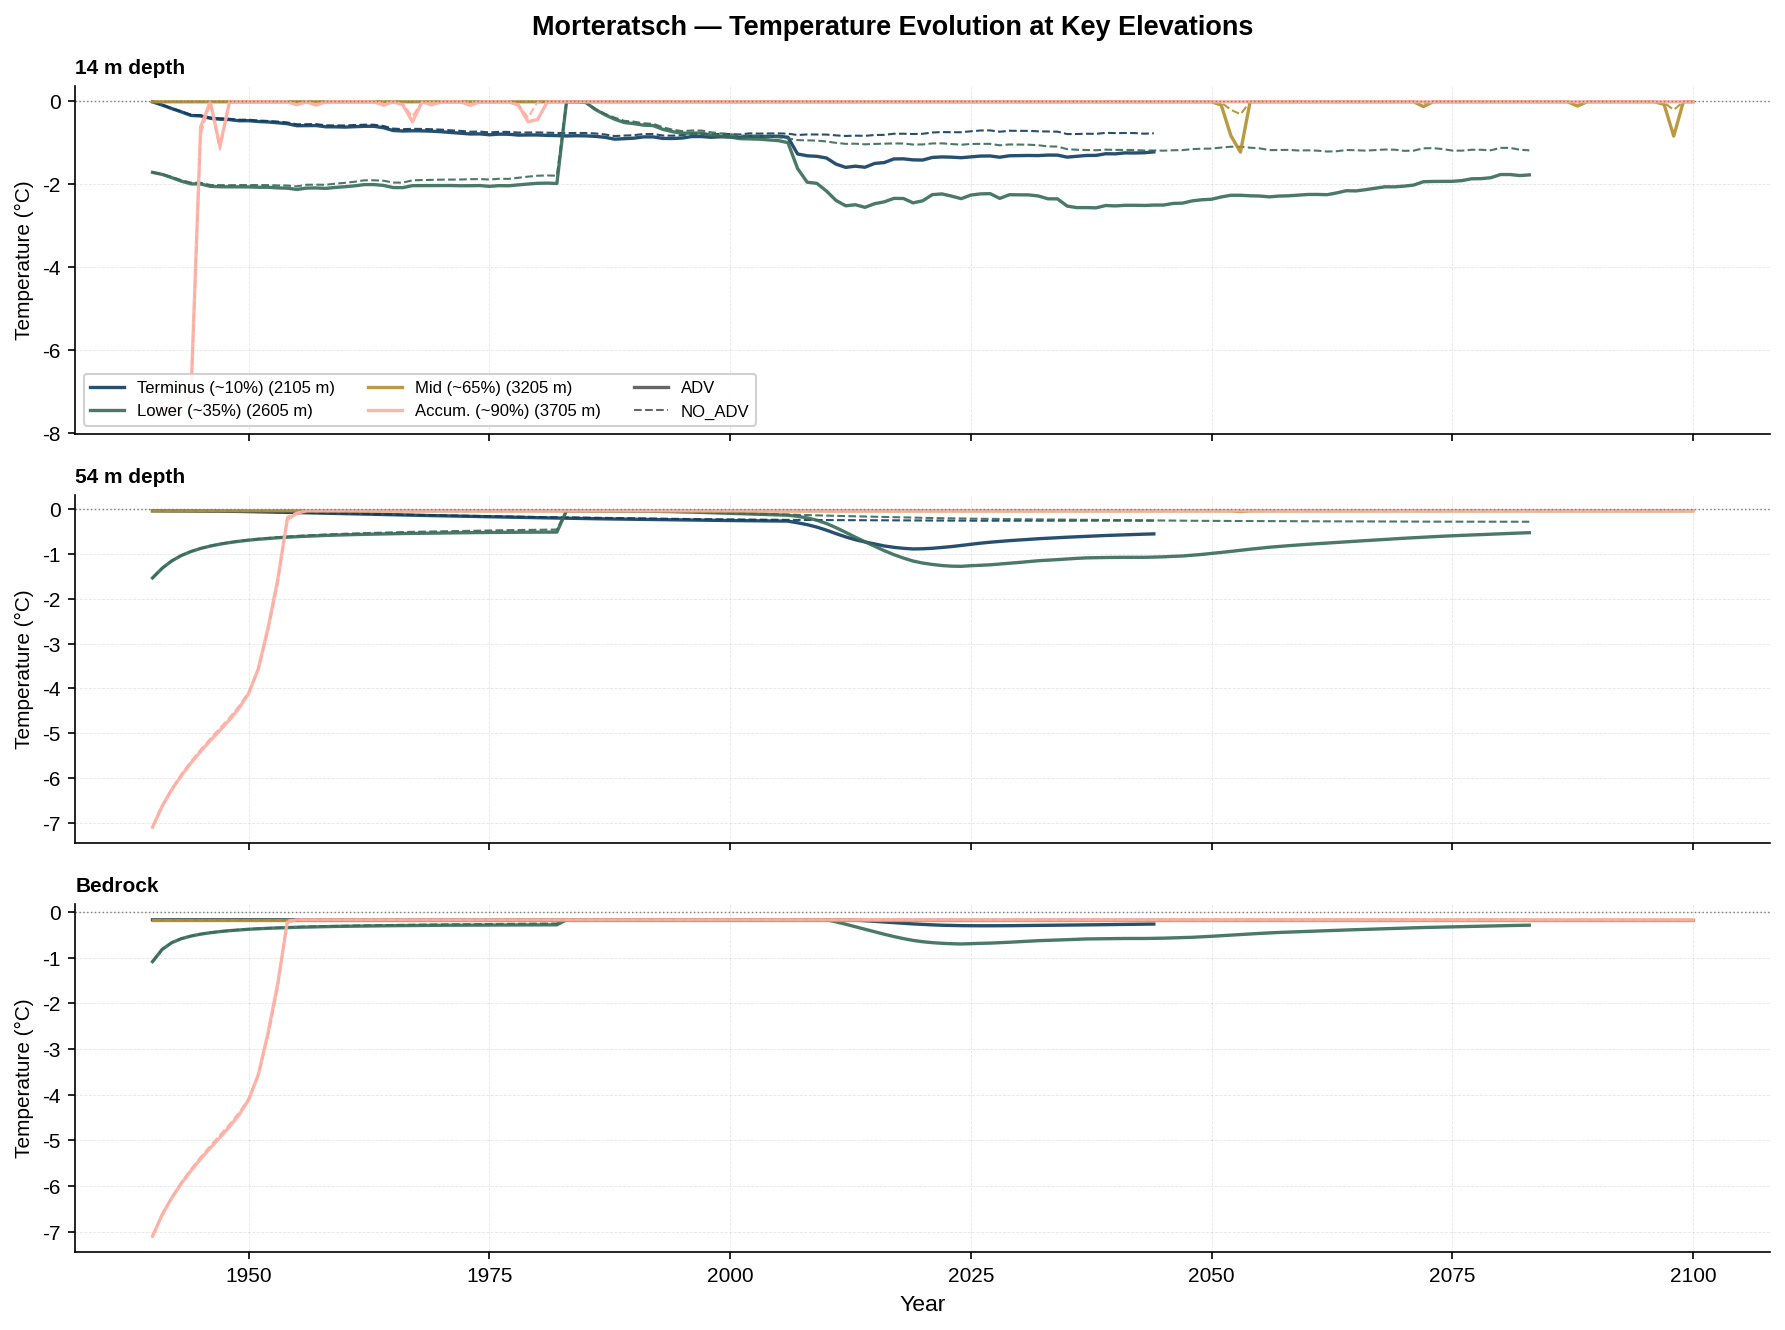

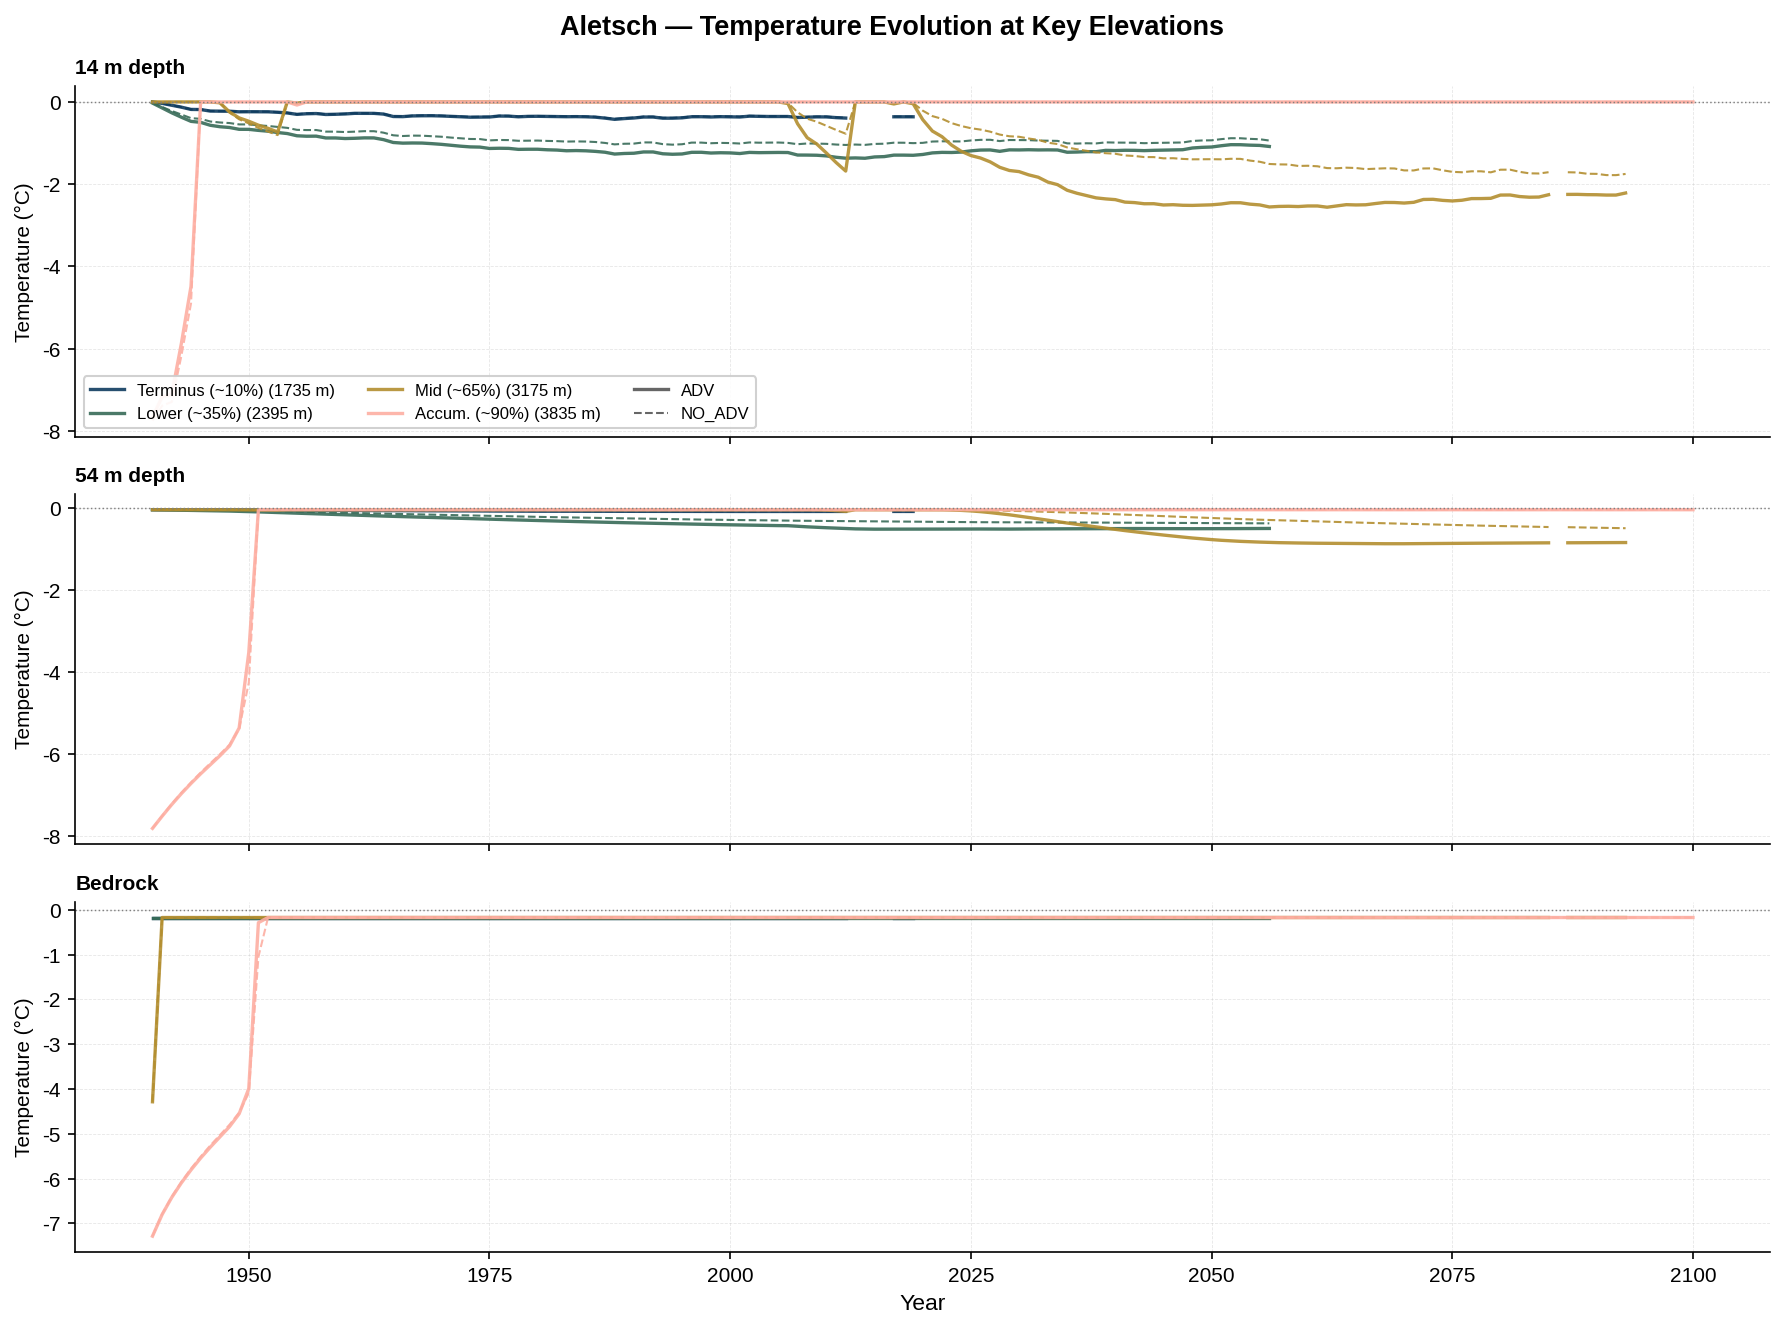

In [84]:
FRAC_ELEVS  = [0.10, 0.35, 0.65, 0.90]
ELEV_LABELS = ['Terminus (~10%)', 'Lower (~35%)', 'Mid (~65%)', 'Accum. (~90%)']
ELEV_COLORS = [cmc.batlow(f) for f in [0.10, 0.32, 0.60, 0.84]]

for gid in glacier_ids:
    name = glacier_names[gid]
    # Use adv run for reference elevation grid (or fallback to no_adv)
    d_ref  = runs_data['adv'].get(gid) or runs_data['no_adv'].get(gid, {})
    elevs  = d_ref.get('elevs')
    if elevs is None:
        continue

    emin, emax = elevs.min(), elevs.max()
    band_idx  = [np.argmin(np.abs(elevs - (emin + f * (emax - emin)))) for f in FRAC_ELEVS]
    band_elev = elevs[band_idx]

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    for ax, key, dep_label in zip(axes,
                                   ['10m', '50m', 'bedrock'],
                                   ['14 m depth', '54 m depth', 'Bedrock']):
        for bi, elbl, col, be in zip(band_idx, ELEV_LABELS, ELEV_COLORS, band_elev):
            for run in RUNS:
                d = runs_data[run].get(gid, {})
                if d.get(key) is None or d.get('years') is None:
                    continue
                ax.plot(d['years'], d[key][bi, :],
                        color=col, lw=1.6 if run == 'adv' else 1.0,
                        ls=RUN_LS[run], alpha=0.9,
                        label=f'{elbl} ({be:.0f} m)' if run == 'adv' else None)
        ax.axhline(0, color='0.5', lw=0.7, ls=':')
        ax.set_ylabel('Temperature (°C)', fontsize=10)
        ax.set_title(dep_label, fontsize=10, loc='left', fontweight='bold')

    # Legend with run linestyle keys
    handles, labels = axes[0].get_legend_handles_labels()
    run_legs = [
        Line2D([0], [0], color='0.4', ls='-',  lw=1.6, label='ADV (solid)'),
        Line2D([0], [0], color='0.4', ls='--', lw=1.0, label='NO_ADV (dashed)'),
    ]
    axes[0].legend(handles + run_legs, labels + ['ADV', 'NO_ADV'],
                    loc='lower left', ncol=3, fontsize=8)

    axes[-1].set_xlabel('Year')
    axes[-1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
    fig.suptitle(f'{name} — Temperature Evolution at Key Elevations',
                  fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

---
## Section 5 — Full Depth Profiles (Point-Profile Output)

Monthly profiles at three fixed elevations from `temp_ID*.dat` (29 depth levels, 1–259 m).  
Solid = ADV, dashed = NO_ADV.  
Left: annual-mean profiles coloured by year. Right: seasonal cycle averaged over all years.

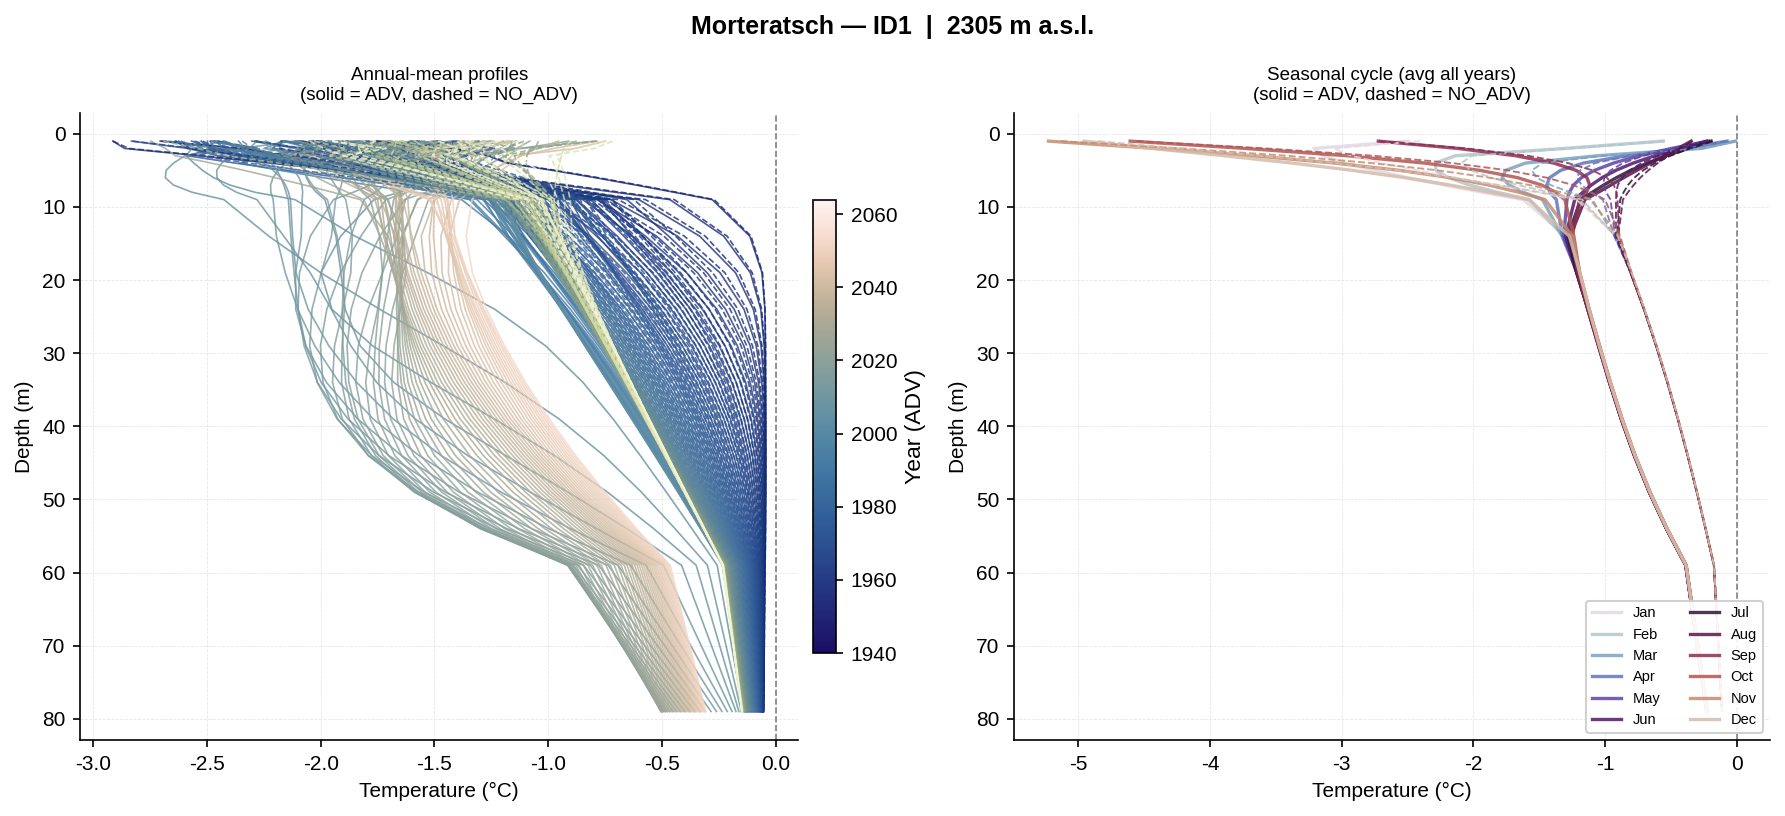

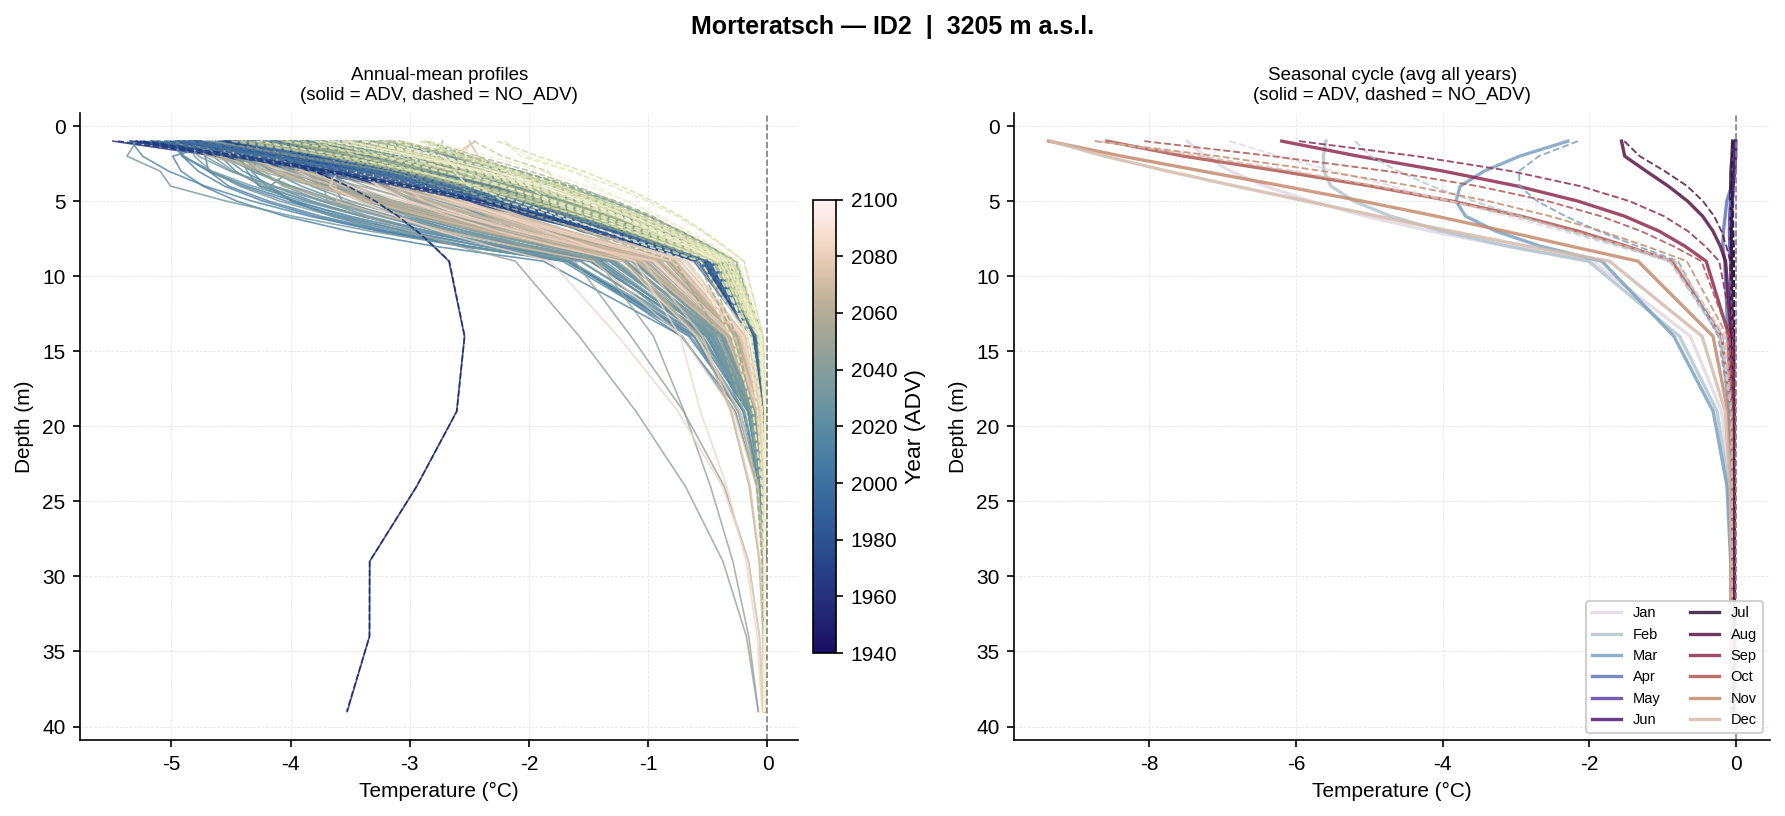

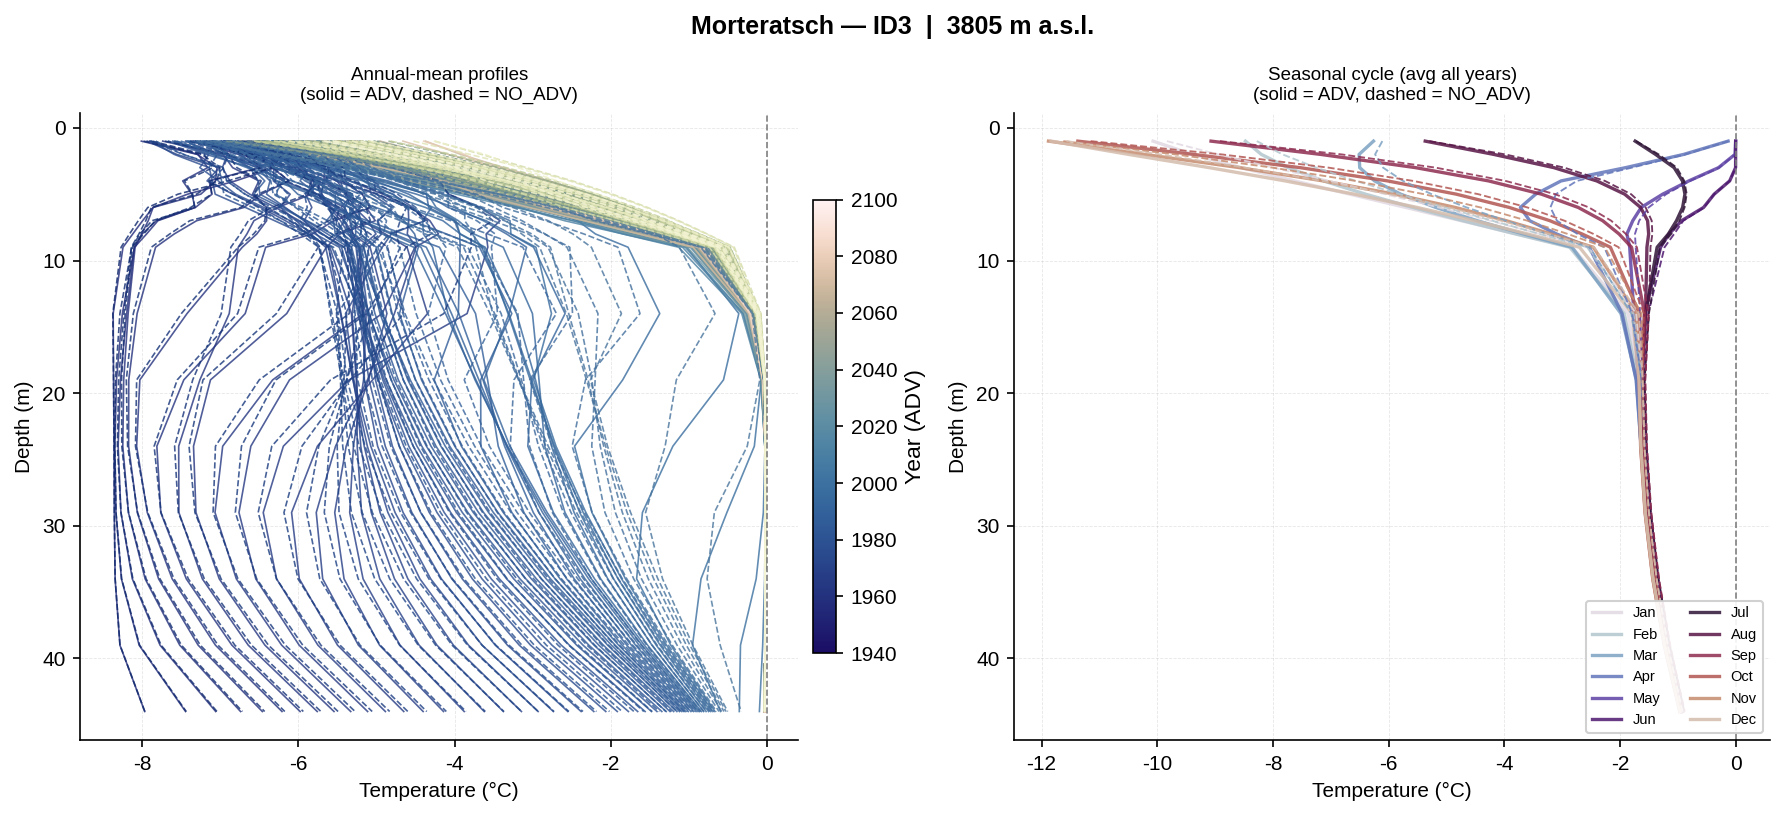

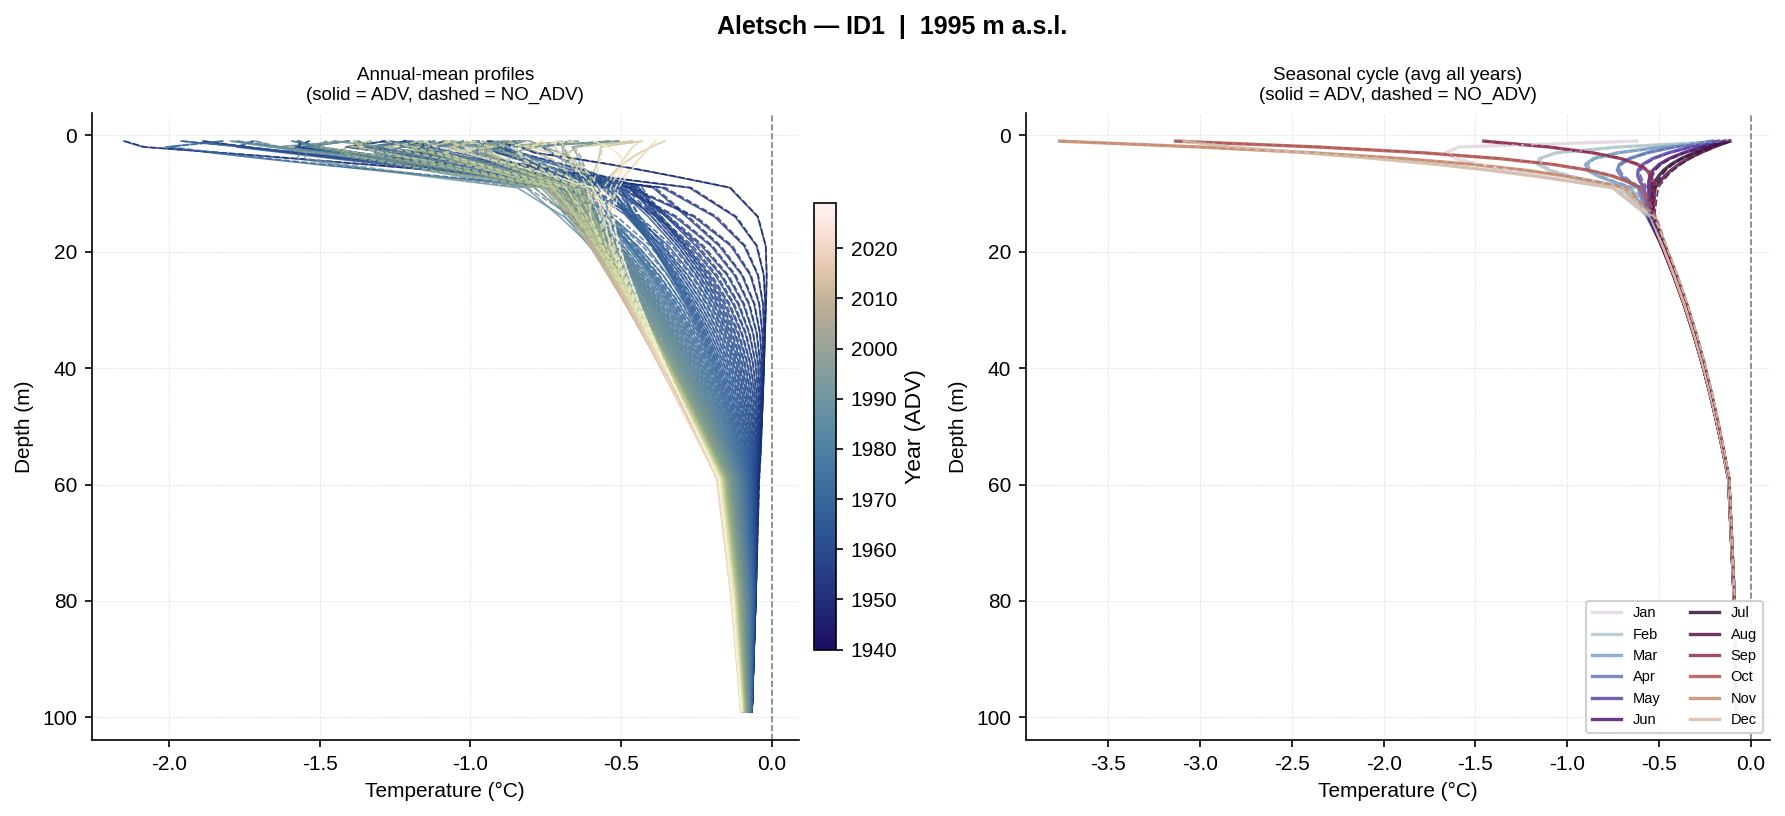

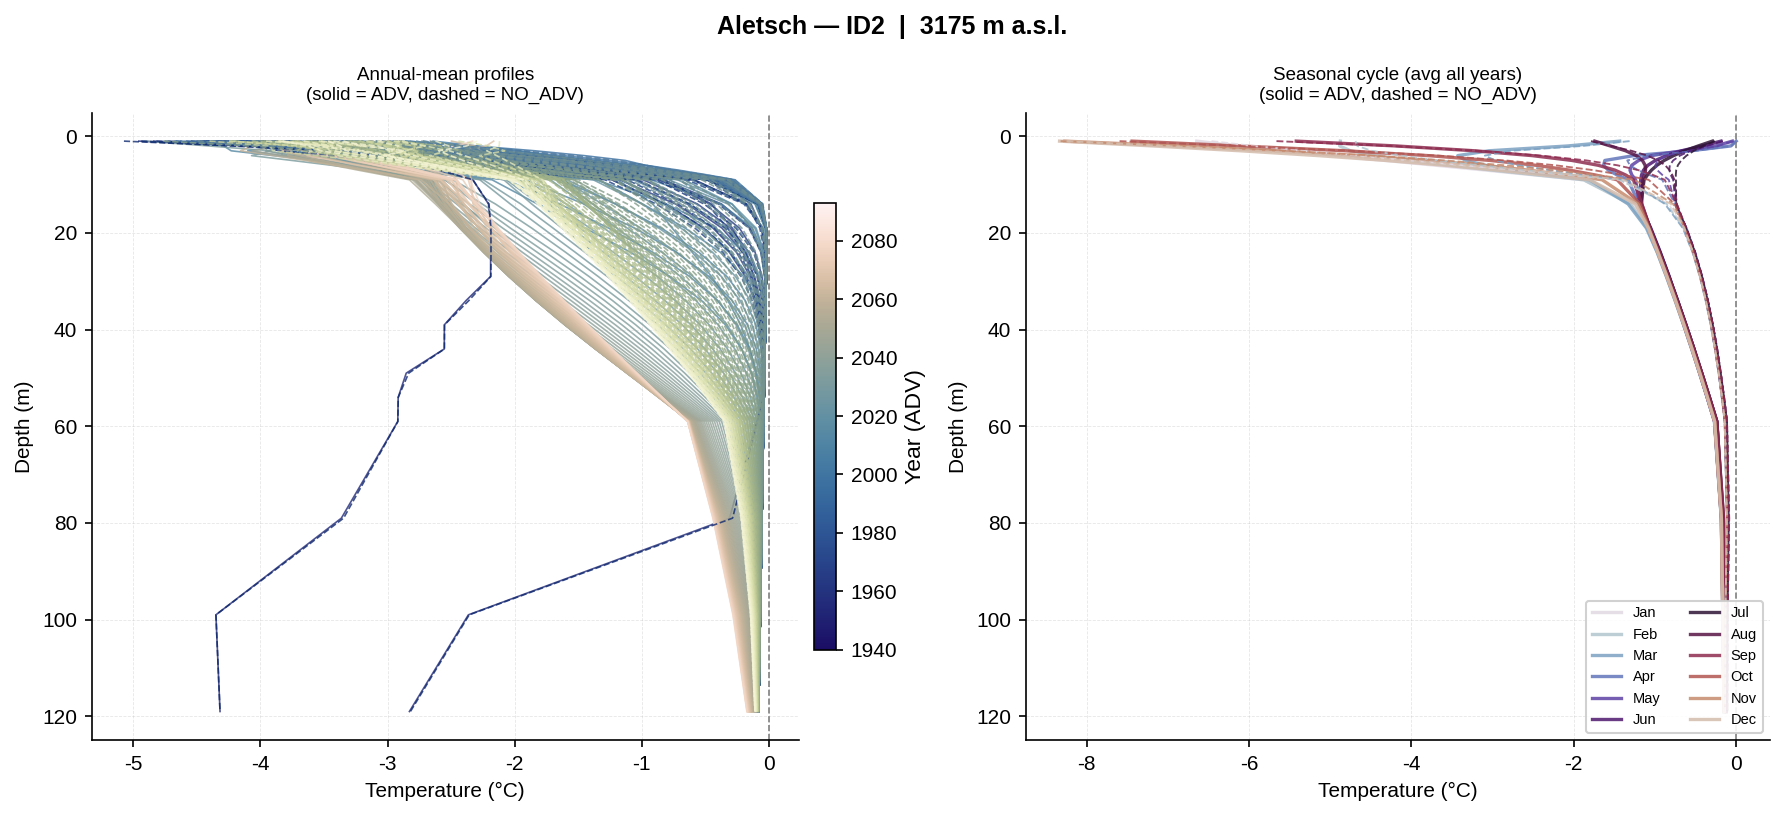

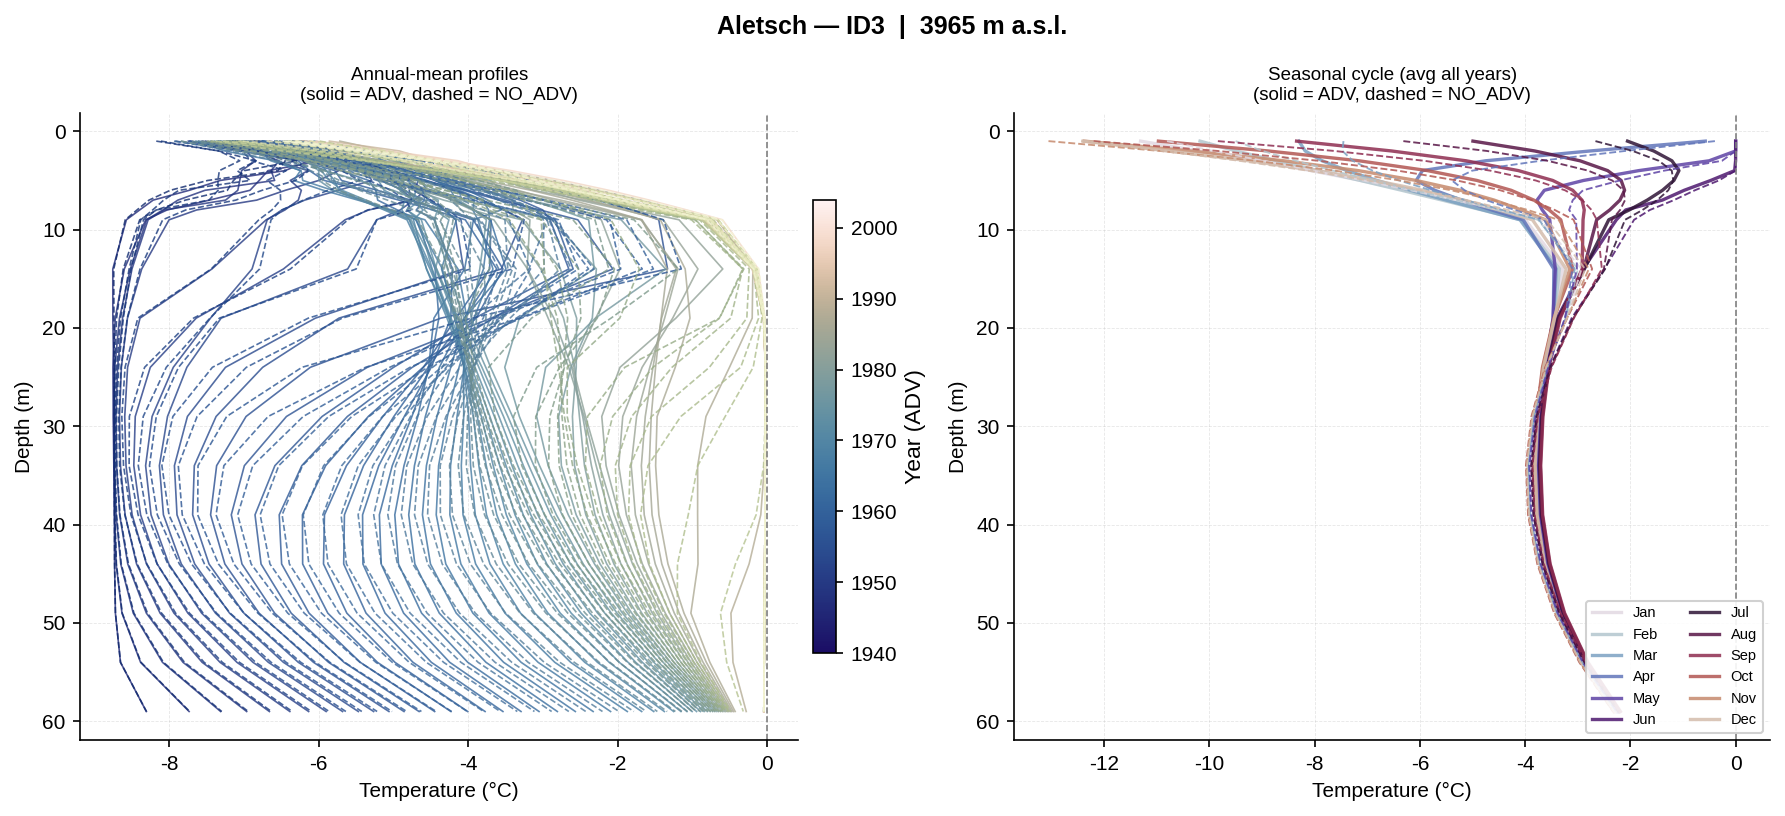

In [85]:
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for gid in glacier_ids:
    name = glacier_names[gid]

    all_pids = set()
    for run in RUNS:
        all_pids |= set(runs_data[run].get(gid, {}).get('profiles', {}).keys())

    if not all_pids:
        print(f'{name}: no point-profile files found (temp_ID*.dat)')
        continue

    for pid in sorted(all_pids):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
        ax_ann, ax_seas = axes
        elev_label = ''
        unique_yrs = []

        for run in RUNS:
            pf = runs_data[run].get(gid, {}).get('profiles', {}).get(pid)
            if pf is None or pf['df'].empty:
                continue
            df     = pf['df']
            depths = pf['depths']
            elev_label = f"{pf['elev_m']} m a.s.l."
            rcol   = RUN_COLORS[run]
            ls     = RUN_LS[run]
            yrs    = sorted(df['year'].unique())
            if run == 'adv':
                unique_yrs = yrs

            # Annual-mean profiles (one curve per year)
            for yi, yr in enumerate(yrs):
                sub = df[df['year'] == yr].iloc[:, 2:].mean()
                t   = yi / max(1, len(yrs) - 1)
                base_cmap = cmc.lapaz if run == 'adv' else cmc.davos
                col = base_cmap(0.1 + 0.8 * t)
                ax_ann.plot(sub.values, depths, color=col, lw=0.8, ls=ls, alpha=0.8)

            # Seasonal cycle (one curve per month)
            for month in range(1, 13):
                sub = df[df['month'] == month].iloc[:, 2:].mean()
                col = plt.cm.twilight((month - 1) / 12)
                ax_seas.plot(sub.values, depths, color=col,
                              lw=1.6 if run == 'adv' else 0.9,
                              ls=ls, alpha=0.85,
                              label=MONTH_NAMES[month - 1] if run == 'adv' else None)

        for ax in axes:
            ax.axvline(0, color='0.5', lw=0.8, ls='--')
            ax.invert_yaxis()
            ax.set_xlabel('Temperature (°C)', fontsize=10)
            ax.set_ylabel('Depth (m)', fontsize=10)

        ax_ann.set_title('Annual-mean profiles\n(solid = ADV, dashed = NO_ADV)', fontsize=9)
        ax_seas.set_title('Seasonal cycle (avg all years)\n(solid = ADV, dashed = NO_ADV)', fontsize=9)
        ax_seas.legend(loc='lower right', ncol=2, fontsize=7)

        if unique_yrs:
            sm = plt.cm.ScalarMappable(cmap=cmc.lapaz,
                                        norm=plt.Normalize(unique_yrs[0], unique_yrs[-1]))
            fig.colorbar(sm, ax=ax_ann, label='Year (ADV)', fraction=0.03, pad=0.02)

        fig.suptitle(f'{name} — {pid}  |  {elev_label}', fontsize=12, fontweight='bold')
        fig.tight_layout()
        plt.show()

---
## Section 6 — Realism Assessment

**6a.** Temperature–elevation lapse rate (both runs).  
**6b.** Distribution histogram of 14 m temperatures.  
**6c.** Advection-file plots (if `advection_write='y'` was set for the ADV run).  
**6d.** Summary statistics table.

/tmp/ipykernel_374929/797713546.py:11: RuntimeWarning: Mean of empty slice
  T_mean = np.nanmean(d['10m'], axis=1)


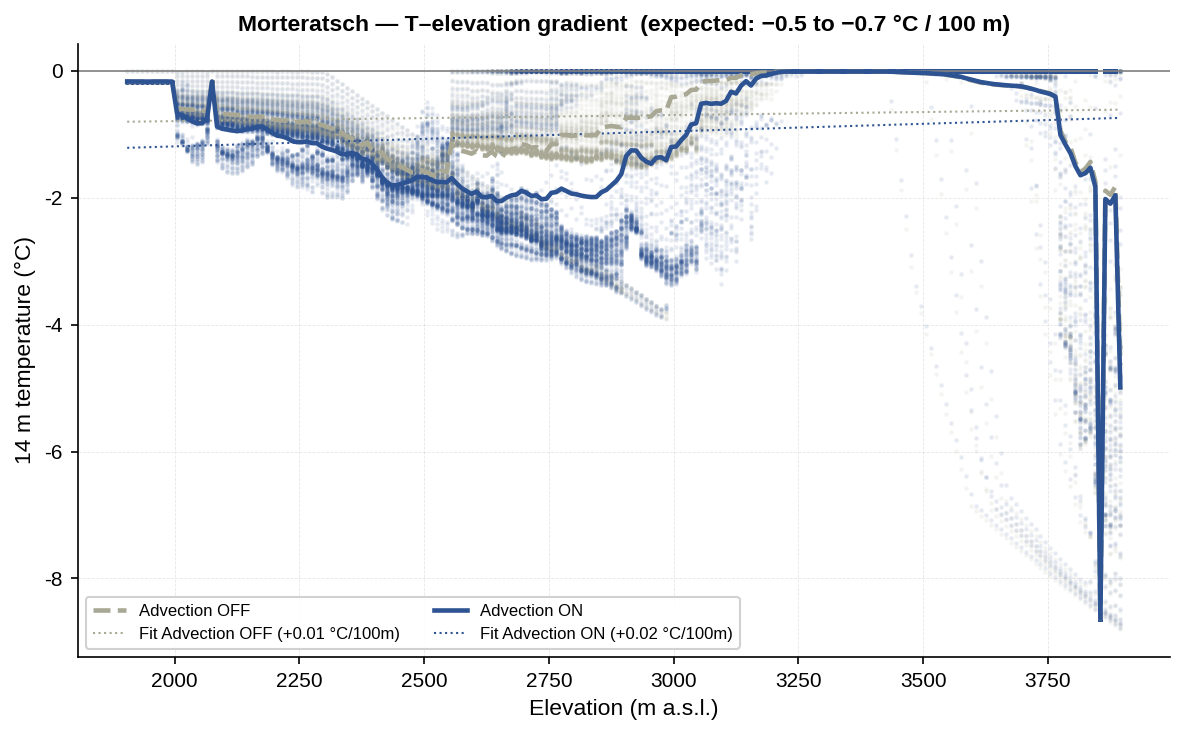

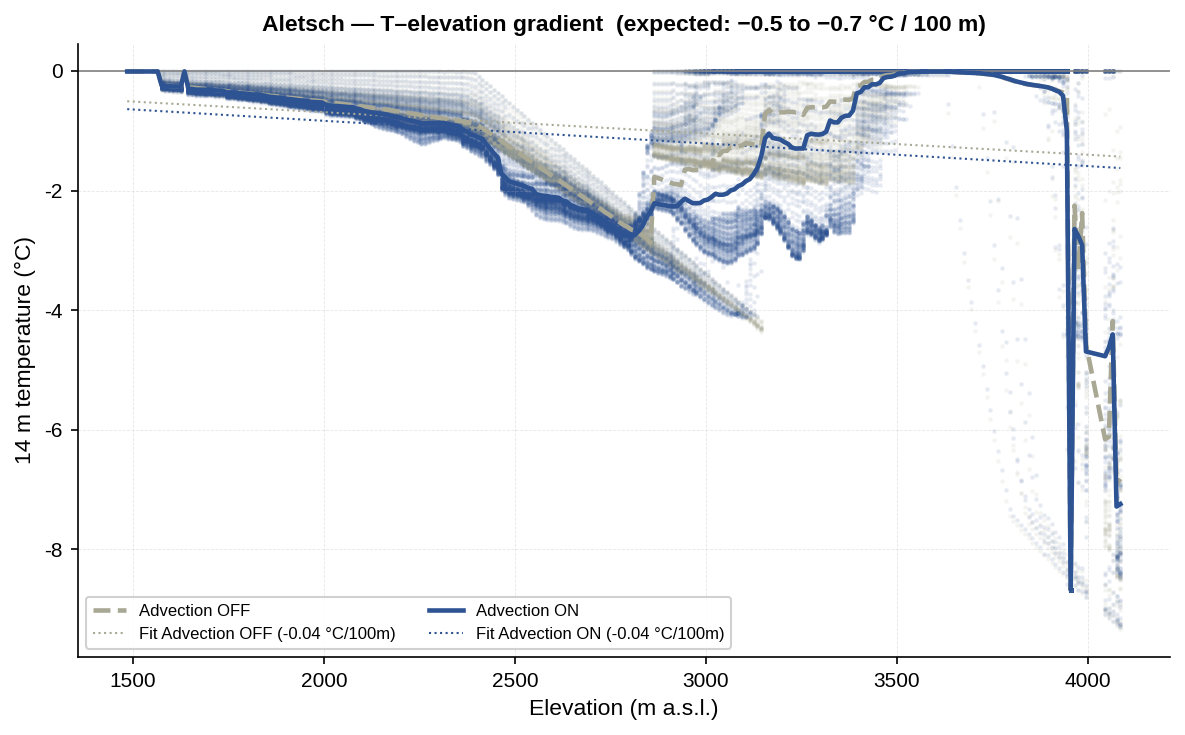

In [86]:
# 6a: Temperature–elevation gradient
for gid in glacier_ids:
    name = glacier_names[gid]
    fig, ax = plt.subplots(figsize=(8, 5))

    for run in ('no_adv', 'adv'):   # plot no_adv first so adv is on top
        d = runs_data[run].get(gid, {})
        if d.get('10m') is None or d.get('elevs') is None:
            continue
        elevs  = d['elevs']
        T_mean = np.nanmean(d['10m'], axis=1)
        valid  = np.isfinite(T_mean)
        col    = RUN_COLORS[run]

        for yi in range(d['10m'].shape[1]):
            ax.scatter(elevs, d['10m'][:, yi], color=col, s=2, alpha=0.07, zorder=1)

        ax.plot(elevs[valid], T_mean[valid], color=col, lw=2.2,
                ls=RUN_LS[run], label=RUN_LABELS[run], zorder=3)

        if valid.sum() >= 5:
            coeffs = np.polyfit(elevs[valid], T_mean[valid], 1)
            lr     = coeffs[0] * 100
            x_fit  = np.linspace(elevs[valid].min(), elevs[valid].max(), 100)
            ax.plot(x_fit, np.polyval(coeffs, x_fit), color=col, lw=1.0, ls=':',
                    label=f'Fit {RUN_LABELS[run]} ({lr:+.2f} °C/100m)')

    ax.axhline(0, color='0.5', lw=0.8, ls='-')
    ax.set_xlabel('Elevation (m a.s.l.)', fontsize=11)
    ax.set_ylabel('14 m temperature (°C)', fontsize=11)
    ax.set_title(f'{name} — T–elevation gradient  (expected: −0.5 to −0.7 °C / 100 m)',
                  fontsize=11, fontweight='bold')
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    plt.show()

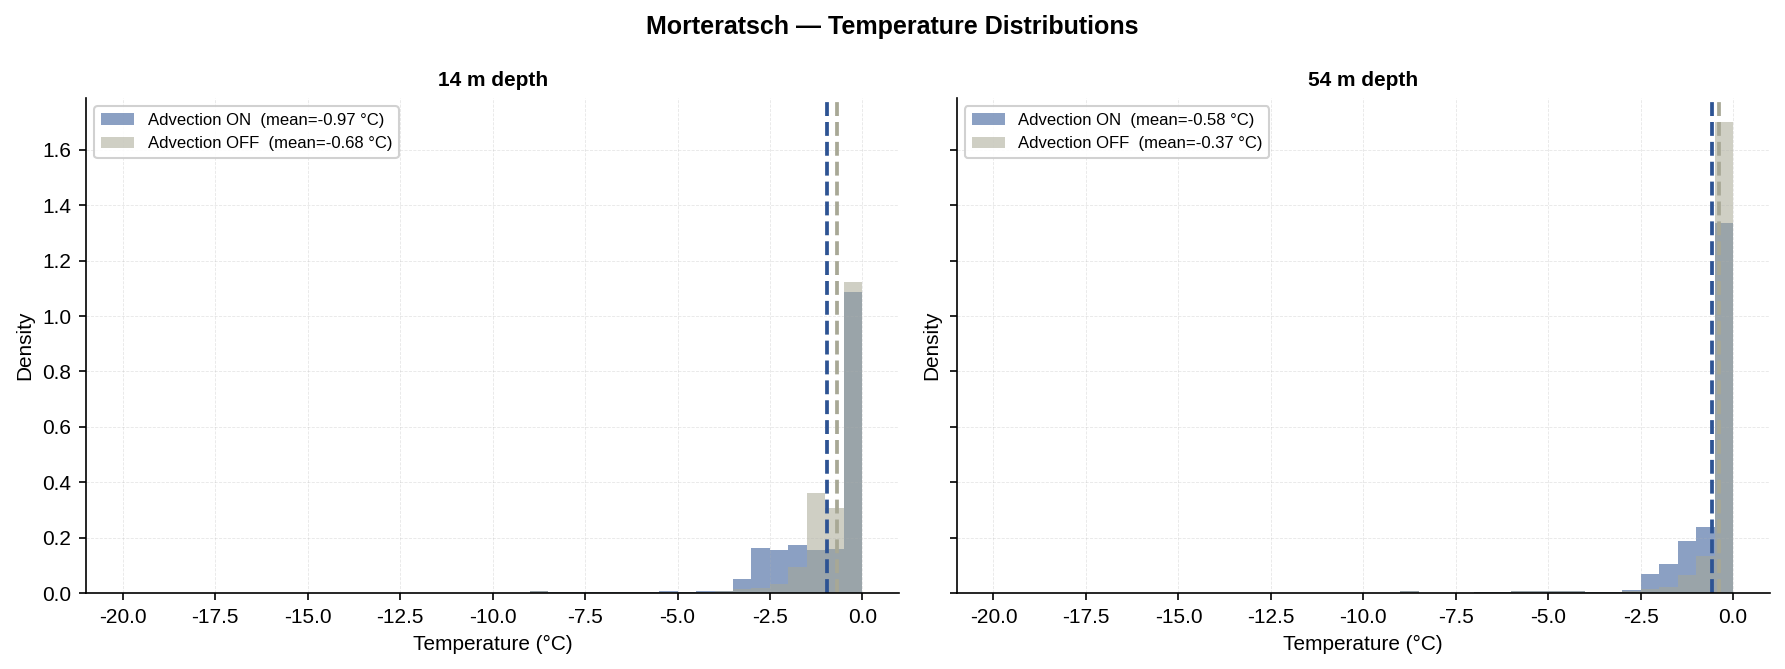

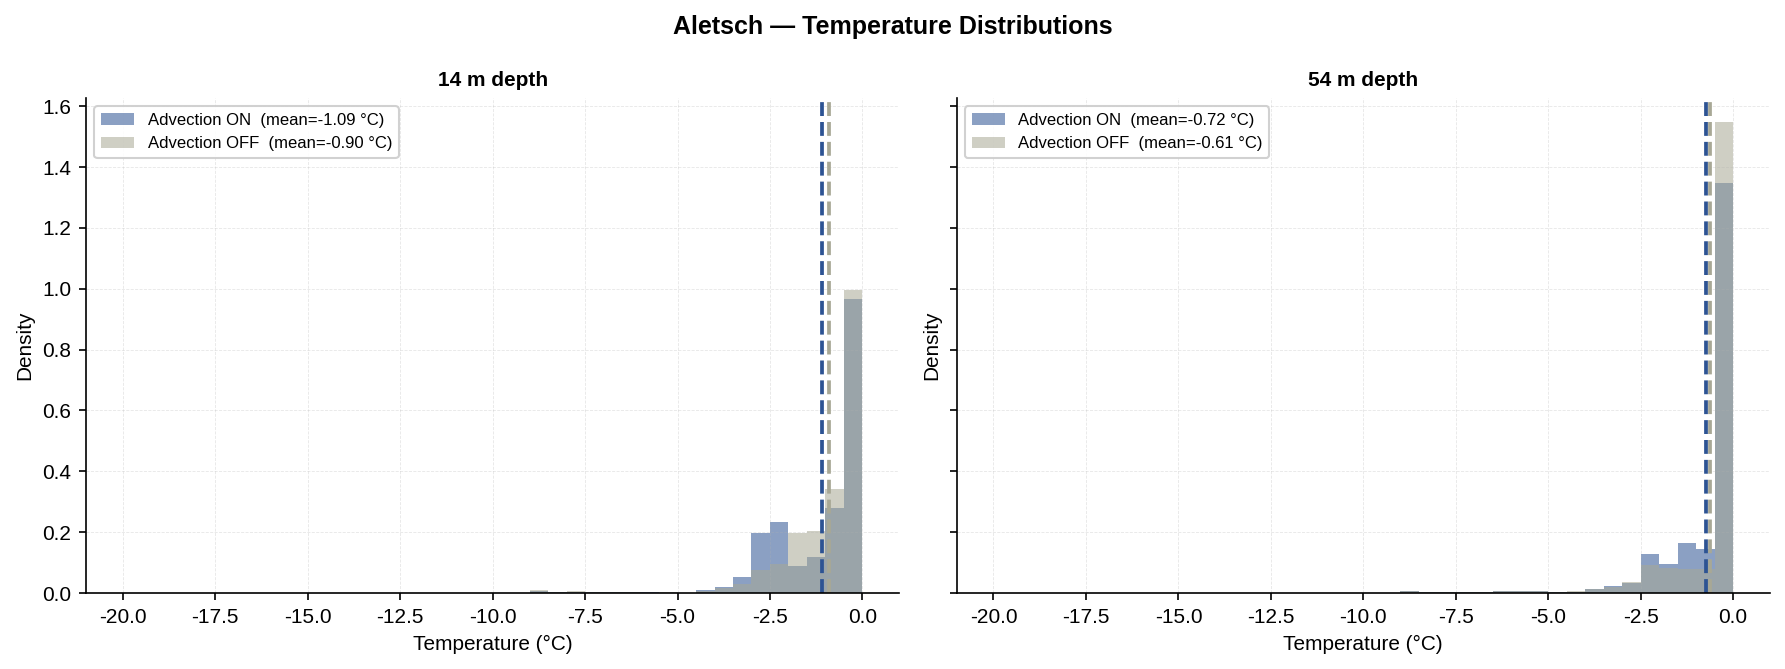

In [87]:
# 6b: Histogram
for gid in glacier_ids:
    name = glacier_names[gid]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    for ax, key, dep_lbl in zip(axes, ['10m', '50m'], ['14 m depth', '54 m depth']):
        bins = np.arange(-20, 0.5, 0.5)
        for run in RUNS:
            d = runs_data[run].get(gid, {})
            if d.get(key) is None:
                continue
            vals = d[key][np.isfinite(d[key])].ravel()
            ax.hist(vals, bins=bins, density=True, alpha=0.55,
                     color=RUN_COLORS[run], label=f'{RUN_LABELS[run]}  (mean={np.mean(vals):.2f} °C)')
            ax.axvline(np.mean(vals), color=RUN_COLORS[run], lw=1.8, ls='--')
        ax.set_xlabel('Temperature (°C)', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(dep_lbl, fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)

    fig.suptitle(f'{name} — Temperature Distributions', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

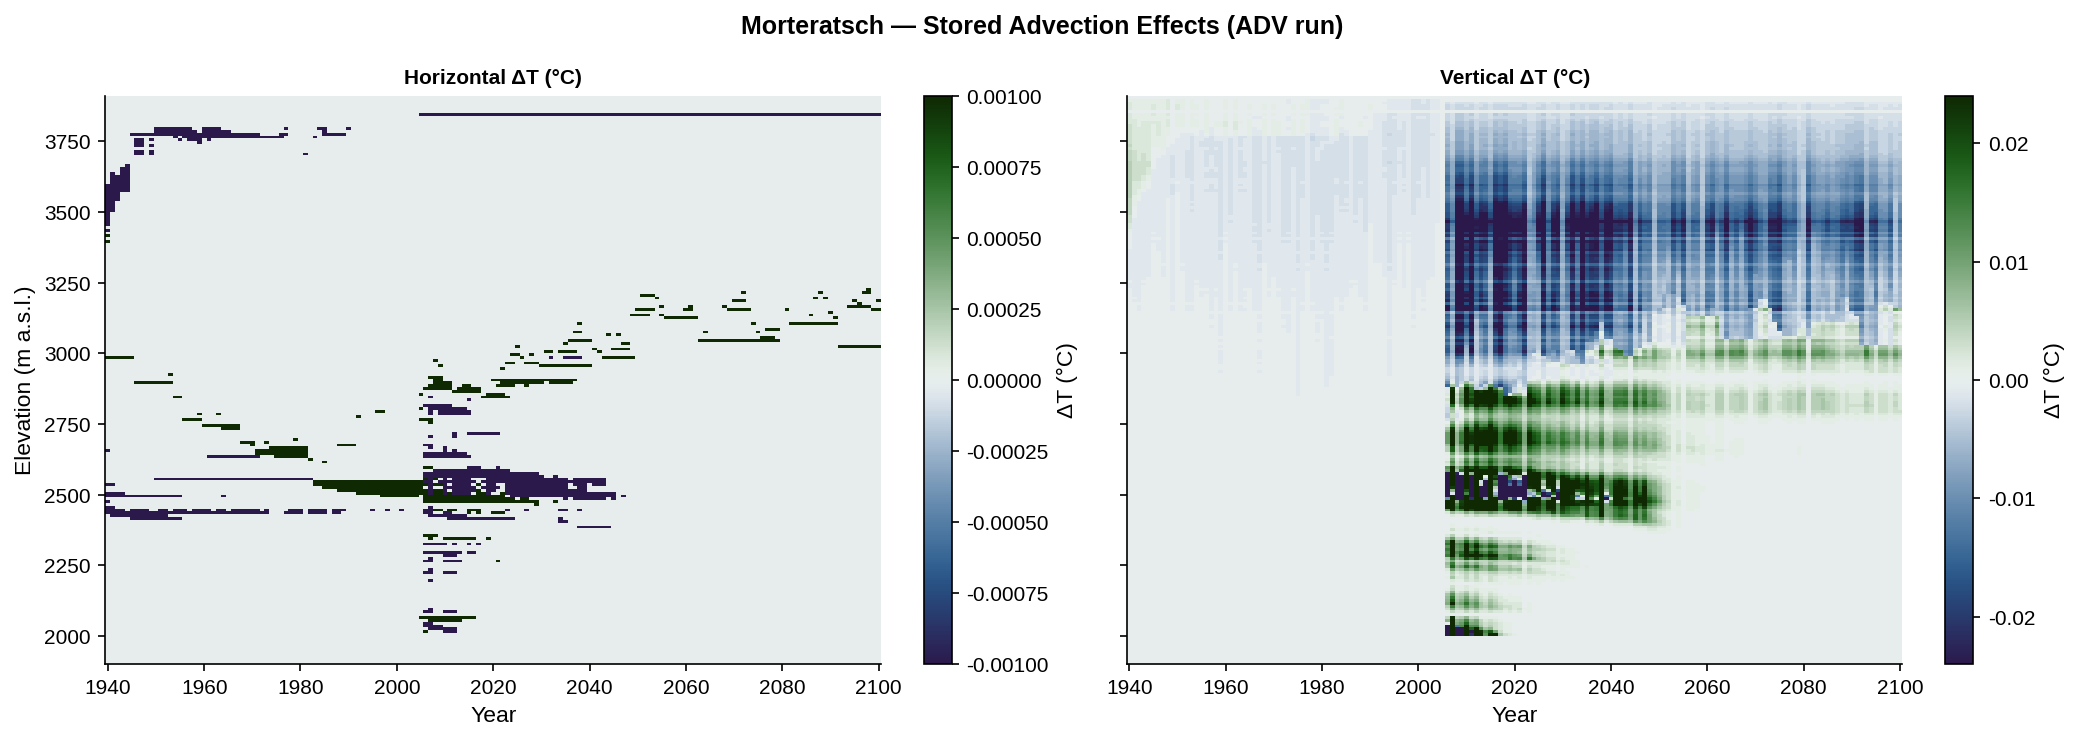

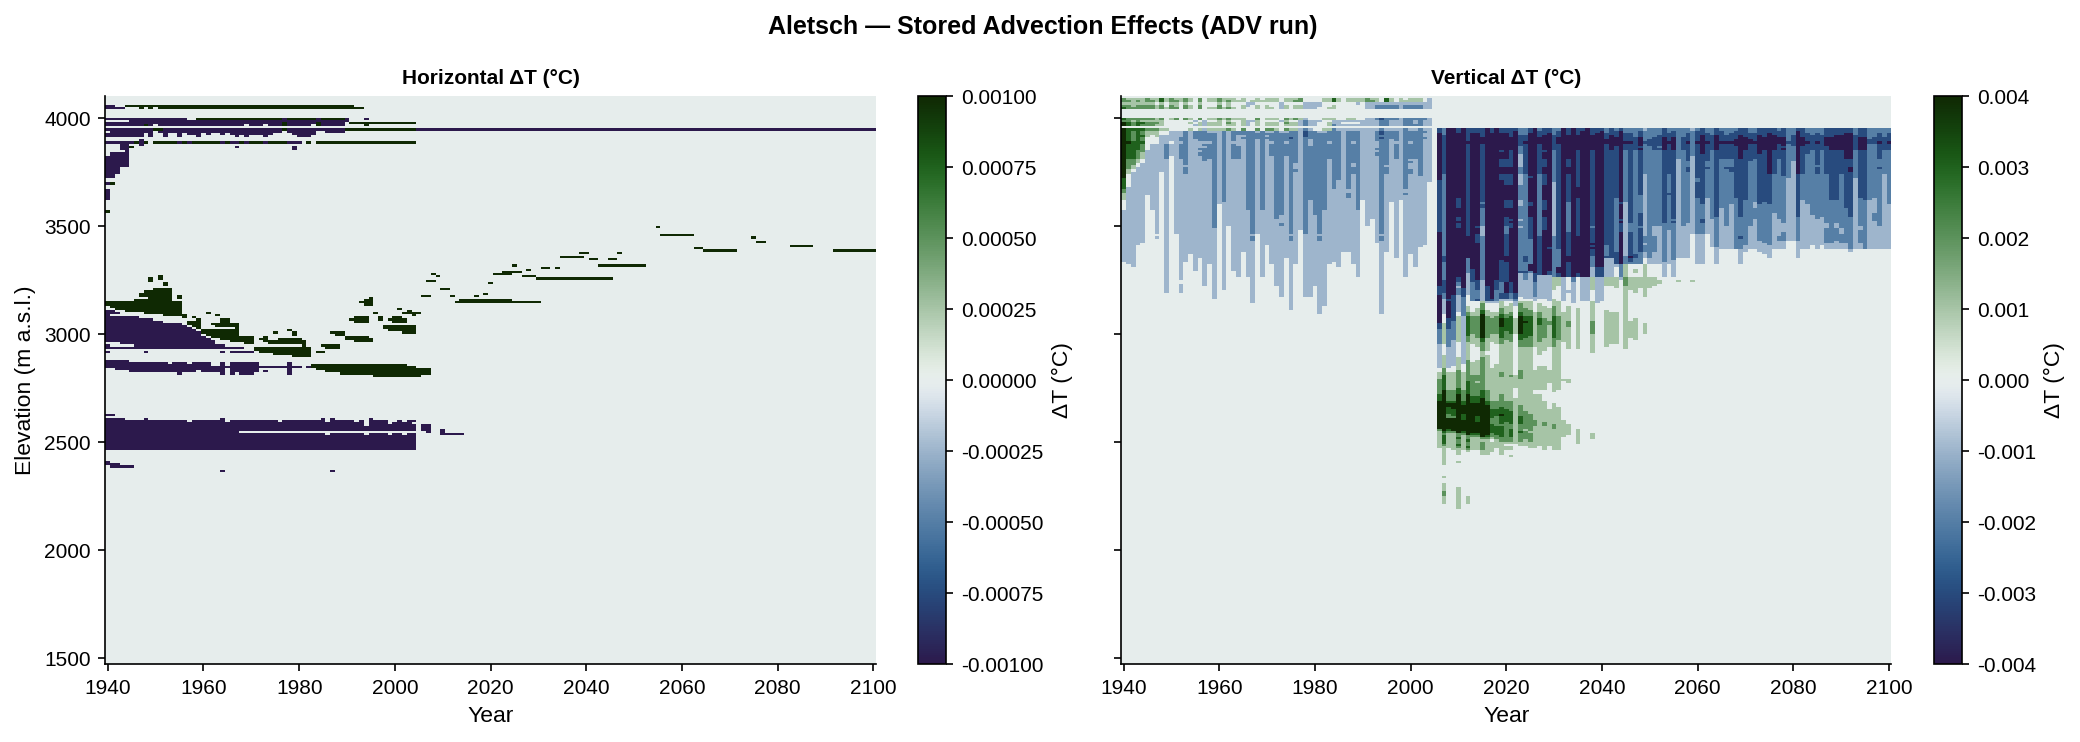

In [88]:
# 6c: Advection files (only written when advection_write='y')
has_adv_files = any(
    runs_data['adv'].get(gid, {}).get('adv_horizontal') is not None
    for gid in glacier_ids
)

if not has_adv_files:
    print('No adv_horizontal_*.dat files in the ADV run.\n'
          'Set advection_write="y" in settings.pro to enable this diagnostic output.')
else:
    for gid in glacier_ids:
        name = glacier_names[gid]
        d    = runs_data['adv'].get(gid, {})
        A_h  = d.get('adv_horizontal')
        A_v  = d.get('adv_vertical')
        if A_h is None:
            continue
        elevs = d['elevs']
        yrs   = d['years']

        panels = [('Horizontal ΔT (°C)', A_h)]
        if A_v is not None:
            panels.append(('Vertical ΔT (°C)', A_v))

        fig, axes = plt.subplots(1, len(panels), figsize=(7 * len(panels), 5), sharey=True)
        if len(panels) == 1:
            axes = [axes]

        for ax, (title, arr) in zip(axes, panels):
            vabs = np.nanpercentile(np.abs(arr[np.isfinite(arr)]), 97)
            im   = ax.pcolormesh(yrs, elevs, arr, cmap=CMAP_DIFF,
                                  vmin=-vabs, vmax=vabs, shading='nearest')
            fig.colorbar(im, ax=ax, label='ΔT (°C)', fraction=0.04)
            ax.set_xlabel('Year')
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.grid(False)
        axes[0].set_ylabel('Elevation (m a.s.l.)')
        fig.suptitle(f'{name} — Stored Advection Effects (ADV run)', fontsize=12, fontweight='bold')
        fig.tight_layout()
        plt.show()

In [89]:
# 6d: Summary statistics table
def _s(arr):
    if arr is None:
        return '   N/A'
    v = arr[np.isfinite(arr)]
    return f'{np.mean(v):+6.2f}°C' if len(v) else '   N/A'

hdr = f"{'Glacier':<13} {'Run':<11} {'14m mean':>10} {'14m min':>10} {'14m max':>10}  {'54m mean':>10} {'Bdrk mean':>11}"
print(hdr)
print('─' * len(hdr))

for gid in glacier_ids:
    name = glacier_names[gid]
    for run in RUNS:
        d  = runs_data[run].get(gid, {})
        t10, t50, tbed = d.get('10m'), d.get('50m'), d.get('bedrock')

        def _minmax(arr):
            if arr is None: return '   N/A', '   N/A'
            v = arr[np.isfinite(arr)]
            return (f'{np.min(v):+6.2f}°C', f'{np.max(v):+6.2f}°C') if len(v) else ('   N/A', '   N/A')

        mi, ma = _minmax(t10)
        print(f'{name:<13} {RUN_LABELS[run]:<11} {_s(t10):>10} {mi:>10} {ma:>10}  '
              f'{_s(t50):>10} {_s(tbed):>11}')

    # ΔT row
    d_a = runs_data['adv'].get(gid, {})
    d_n = runs_data['no_adv'].get(gid, {})
    cyrs, ia, ib = align_years(d_a, d_n)
    if cyrs is not None:
        dt10 = np.nanmean(d_a['10m'][:, ia] - d_n['10m'][:, ib]) if (d_a.get('10m') is not None and d_n.get('10m') is not None) else np.nan
        dt50 = np.nanmean(d_a['50m'][:, ia] - d_n['50m'][:, ib]) if (d_a.get('50m') is not None and d_n.get('50m') is not None) else np.nan
        print(f"{'':13} {'Δ ADV−NOADV':<11} {dt10:>+9.3f}°C {'':>10} {'':>10}  {dt50:>+9.3f}°C")
    print()

print('Reference ranges for Alpine glaciers (Haeberli & Funk 1991, Suter et al. 2001):')
print('  14 m (≈ 10 m firn T): −10 to 0 °C   (cold accum. zone; temperate ablation zone)')
print('  54 m:                   −8 to 0 °C   (cold only in uppermost accum. zone)')
print('  Bedrock:                −2 to 0 °C   (mostly temperate in Alpine glaciers)')

Glacier       Run           14m mean    14m min    14m max    54m mean   Bdrk mean
──────────────────────────────────────────────────────────────────────────────────
Morteratsch   Advection ON    -0.97°C    -8.78°C    -0.01°C     -0.58°C     -0.48°C
Morteratsch   Advection OFF    -0.68°C    -8.80°C    -0.01°C     -0.37°C     -0.38°C
              Δ ADV−NOADV    -0.287°C                           -0.210°C

Aletsch       Advection ON    -1.09°C    -9.30°C    -0.01°C     -0.72°C     -0.49°C
Aletsch       Advection OFF    -0.90°C    -9.34°C    -0.01°C     -0.61°C     -0.49°C
              Δ ADV−NOADV    -0.186°C                           -0.107°C

Reference ranges for Alpine glaciers (Haeberli & Funk 1991, Suter et al. 2001):
  14 m (≈ 10 m firn T): −10 to 0 °C   (cold accum. zone; temperate ablation zone)
  54 m:                   −8 to 0 °C   (cold only in uppermost accum. zone)
  Bedrock:                −2 to 0 °C   (mostly temperate in Alpine glaciers)


---
## Interpretation Guide

**Physical expectations for the ADV − NO_ADV difference:**
- **Ablation zone, 14 m and 54 m depth** → ΔT < 0: cold accumulation-zone ice advected downglacier displaces warmer local ice → advection cools the ablation zone.
- **Accumulation zone** → ΔT ≈ 0 from horizontal advection (ice originates from same altitude range). Vertical advection (burial of cold firn) may give small negative ΔT at depth.
- **Shallow (2 m)** → ΔT ≈ 0: seasonal cycle dominates; advection of ice over annual timescales is negligible at this depth.
- **Larger ΔT magnitude at 54 m vs 14 m**: advection signal is cumulative with depth.

**Model features and limitations:**

| Feature | Status |
|---------|--------|
| Vertical heat conduction | ✅ Explicit FD, 30 layers |
| Latent heat from refreezing | ✅ Firn permeability model |
| Geothermal flux at bedrock | ✅ Spatially variable |
| Horizontal advection (upwind FD) | ✅ Optional; velocity from GloGEMflow SIA |
| Vertical advection (burial/emergence) | ✅ Same flag |
| Strain heating | ❌ Not implemented |
| Lateral heat conduction | ❌ 1D column model |

Annual **maximum** temperature is stored, which is biased warm relative to annual mean — most relevant for comparing runs, not for absolute validation.